# Radar measurement characterization: report updates

<font color='red'>KI-Nutzung</font>
- Texte können teilweise, nicht vollständig, mit KI ausformuliert werden
- am anfang des papers einen absatz zum deklarieren
- brainstorming in ordnung, muss nicht deklariert werden

- Failures gehören nicht dokumentiert

**How to run**: kernel = the repo root `.venv`. Runs top to bottom; the load
cell takes ~2 min; the results section runs the real C++ solver (~1 min, skip
with `RUN_SOLVER = False`).

In [1]:
# Setup: repo-relative paths, imports, shared helpers
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'analysis' / 'lib').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('repo root not found (run from inside the repo)')
    REPO_ROOT = REPO_ROOT.parent
ANALYSIS = REPO_ROOT / 'analysis'
for p in (ANALYSIS, ANALYSIS / 'lib', ANALYSIS / 'adaptive_knots'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.signal import butter, filtfilt
from scipy.spatial.transform import Rotation, Slerp
from scipy.stats import linregress

from config_loader import load_config
from rosbag_loader.loader import load_bag_topics, stitch_cpu_counter_resets_improved
from radar_velocity_utils import (compute_doppler_residuals, rotation_matrix_from_euler,
                                  unwrap_doppler, quat_to_rotation_matrix)

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'figure.figsize': (12, 4)})

# --- helpers copied from analysis/characterize_radar.py ---
def robust_sigma(x):
    '''1.4826 * MAD: sigma estimate insensitive to heavy tails.'''
    x = np.asarray(x)
    return 1.4826 * np.median(np.abs(x - np.median(x))) if len(x) else np.nan

def binned_sigma(x, residuals, edges, min_n=30):
    centers, sigmas, counts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x < hi)
        if np.sum(m) >= min_n:
            centers.append(0.5 * (lo + hi))
            sigmas.append(robust_sigma(residuals[m]))
            counts.append(int(np.sum(m)))
    return np.array(centers), np.array(sigmas), np.array(counts)

def binned_sigma_bias(x, residuals, edges, min_n=30):
    centers, sigmas, biases, counts = [], [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x < hi)
        if np.sum(m) >= min_n:
            centers.append(0.5 * (lo + hi))
            sigmas.append(robust_sigma(residuals[m]))
            biases.append(float(np.median(residuals[m])))
            counts.append(int(np.sum(m)))
    return np.array(centers), np.array(sigmas), np.array(biases), np.array(counts)

OMEGA_BIN_EDGES = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 14.0])
print(f'repo root: {REPO_ROOT}')

repo root: /home/mouse/MyData/radar-iwr6843-driver


In [2]:
# Load the three bags and compute per-point Doppler residuals (cached across re-runs)
CFG = load_config()
BAGS_CFG = CFG['bags']['bags']; TIMING = CFG['bags']['timing']
RC = CFG['bags'].get('radar_config', {}); EXT = CFG['extrinsics']

# Deployed extrinsics: pitch locked at the measured 27.5 deg (extrinsics.yaml keeps
# 25.5 only as the batch self-cal seed)
R_BS = rotation_matrix_from_euler(*np.radians([180.0, 27.5, 0.0]))
T_BS = np.array(EXT['translation_body_m'])
RADAR_OFF = EXT['imu_mocap_offset_sec'] - EXT['radar_imu_offset_sec']
IMU_OFF = EXT['imu_mocap_offset_sec']

BAG_KEYS = ['slow_racing_best_velocity', 'fast_racing_best_velocity',
            'backflips_best_velocity']
SHORT = {'slow_racing_best_velocity': 'slow racing',
         'fast_racing_best_velocity': 'fast racing',
         'backflips_best_velocity': 'backflips'}
COLOR = {'slow_racing_best_velocity': 'tab:blue',
         'fast_racing_best_velocity': 'tab:orange',
         'backflips_best_velocity': 'tab:red'}

D = globals().get('D', {})
for key in BAG_KEYS:
    if key in D:
        continue
    v_max = RC.get('best_velocity' if 'best_velocity' in key else 'default',
                   {}).get('v_max', 4.99)
    data = load_bag_topics(str(REPO_ROOT / BAGS_CFG[key]), verbose=False)
    t0 = data.start_time + TIMING[key][0]
    t1 = t0 + TIMING[key][1]
    radar = [f for f in data.radar_velocity
             if t0 <= f.timestamp <= t1 and f.positions is not None]
    imu = [m for m in data.imu_data if t0 <= m.timestamp <= t1]
    # pre-flight tail: the vehicle sits on the ground before t0, first with
    # motors off.  True rate is zero and true specific force is g there, so
    # it is the one reference-free IMU measurement this dataset contains
    # (used in section 5).
    imu_pre = [m for m in data.imu_data if m.timestamp < t0]
    mocap_pre = [p for p in data.mocap_pose if p.timestamp < t0]
    states = data.agiros_state          # full range kept for interpolation
    dres = compute_doppler_residuals(states, radar, T_BS, R_BS,
                                     time_offset=RADAR_OFF, min_range=0.2)
    meas, pred = dres['measurements'], dres['predictions']
    unw = unwrap_doppler(meas, pred, v_max)   # ground-truth de-aliased
    r = unw - pred                            # the working residual everywhere below
    fi = np.array(dres['frame_indices']); pi = np.array(dres['point_indices'])
    st_t = np.array([s.timestamp for s in states])
    om_interp = interp1d(st_t, np.array([s.angular_velocity for s in states]),
                         axis=0, kind='linear', bounds_error=False,
                         fill_value='extrapolate')
    t_pts = np.array([radar[i].timestamp for i in fi]) + RADAR_OFF
    om_pts = np.linalg.norm(om_interp(t_pts), axis=1)
    u_z = np.array([radar[f].positions[p][2] / np.linalg.norm(radar[f].positions[p])
                    for f, p in zip(fi, pi)])
    D[key] = dict(v_max=v_max, t0=t0, t1=t1, radar=radar,
                  imu_pre=imu_pre, mocap_pre=mocap_pre,
                  bag_t0=data.start_time,
                  radar_full=list(data.radar_velocity), imu=imu, states=states,
                  mocap_pose=list(data.mocap_pose), dres=dres, meas=meas, pred=pred,
                  unw=unw, r=r, aliased=(unw != meas), fi=fi, pi=pi, om_pts=om_pts,
                  u_z=u_z, om_interp=om_interp, st_t=st_t)
    del data
    print(f'loaded {key}')

print(f"\n{'bag':<14} {'frames':>7} {'pts/frame':>10} {'frames<5':>9} "
      f"{'IMU rate':>9} {'v_max':>6}")
for key in BAG_KEYS:
    d = D[key]
    ppf = np.array([f.num_points() for f in d['radar']])
    imu_rate = (len(d['imu']) - 1) / (d['imu'][-1].timestamp - d['imu'][0].timestamp)
    print(f"{SHORT[key]:<14} {len(d['radar']):>7} {np.median(ppf):>10.0f} "
          f"{100 * np.mean(ppf < 5):>8.0f}% {imu_rate:>7.0f}Hz {d['v_max']:>6.3f}")
print('\npaper (Table: measured radar data properties): pts/frame 13 / 11 / 10, '
      'frames<5: 6 / 12 / 9 %')

# RANSAC prefilter masks (deployment order: consensus on unwrapped Doppler),
# built once and shared by sections 2, 3, and 5.
_rng_masks = np.random.default_rng(0)

def ransac_mask(P, v, thresh=0.15, iters=150):
    n = len(v)
    if n < 5:
        return np.ones(n, dtype=bool)
    Hn = P / np.maximum(np.linalg.norm(P, axis=1, keepdims=True), 1e-6)
    best = None
    for _ in range(iters):
        i3 = _rng_masks.choice(n, 3, replace=False)
        try:
            vc = np.linalg.solve(Hn[i3], v[i3])
        except np.linalg.LinAlgError:
            continue
        inl = np.abs(Hn @ vc - v) < thresh
        if best is None or inl.sum() > best.sum():
            best = inl
    return best if best is not None and best.sum() >= 5 else np.ones(n, dtype=bool)

masks = {}
for key in BAG_KEYS:
    d = D[key]
    masks[key] = {}
    for i, f in enumerate(d['radar']):
        if f.num_points() < 5:
            continue
        v = np.asarray(f.velocities, float).copy()
        sel = d['fi'] == i
        v[d['pi'][sel]] = d['unw'][sel]
        masks[key][i] = ransac_mask(np.asarray(f.positions, float), v)

loaded slow_racing_best_velocity


loaded fast_racing_best_velocity


loaded backflips_best_velocity

bag             frames  pts/frame  frames<5  IMU rate  v_max
slow racing        258         13        6%     993Hz  3.136
fast racing        179         11       12%     993Hz  3.136
backflips          181         10        9%     993Hz  3.136

paper (Table: measured radar data properties): pts/frame 13 / 11 / 10, frames<5: 6 / 12 / 9 %


## 1. Measurement arrival timing

Three returns determine a 3D ego-velocity exactly; five is the practical floor
for any outlier-robust per-frame fit. 6-12% of frames are below it.


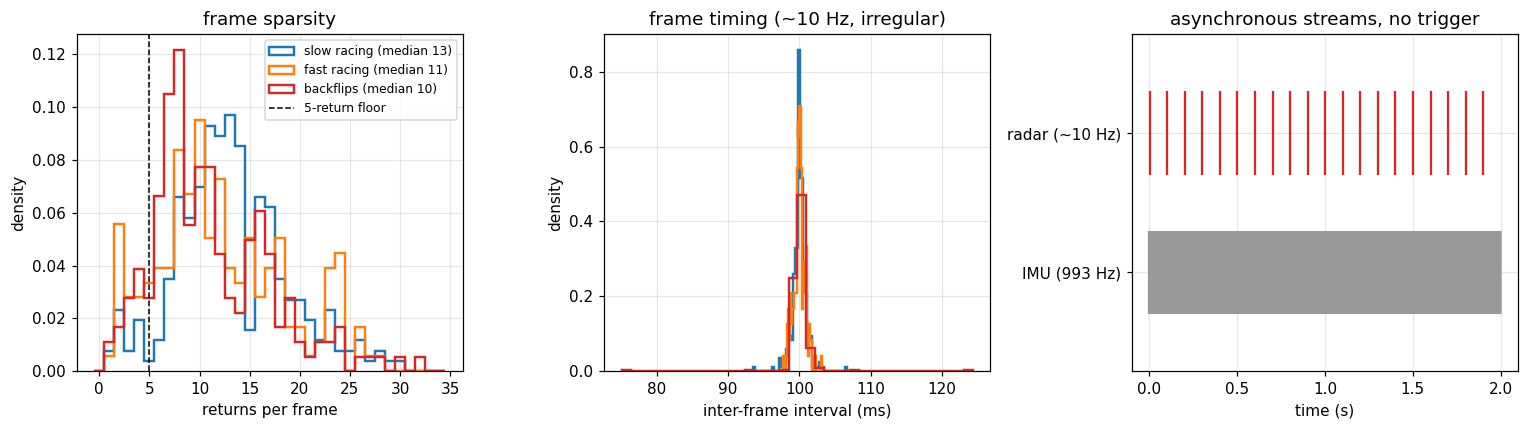

In [3]:
# 2a. Rates and sparsity: 10 Hz radar vs ~1 kHz IMU, and thin frames
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for key in BAG_KEYS:
    d = D[key]
    ppf = np.array([f.num_points() for f in d['radar']])
    axes[0].hist(ppf, bins=np.arange(0, 36) - 0.5, histtype='step', lw=1.6,
                 label=f"{SHORT[key]} (median {np.median(ppf):.0f})",
                 color=COLOR[key], density=True)
    ft = np.array([f.timestamp for f in d['radar']])
    axes[1].hist(1e3 * np.diff(ft), bins=40, histtype='step', lw=1.6,
                 color=COLOR[key], density=True)
axes[0].axvline(5, color='k', ls='--', lw=1, label='5-return floor')
axes[0].set_xlabel('returns per frame'); axes[0].set_ylabel('density')
axes[0].set_title('frame sparsity')
axes[0].legend(fontsize=8)
axes[1].set_xlabel('inter-frame interval (ms)'); axes[1].set_ylabel('density')
axes[1].set_title('frame timing (~10 Hz, irregular)')

# a 2 s slice of arrival times: radar frames vs IMU samples
d = D['fast_racing_best_velocity']
tt0 = d['t0'] + 0.5 * (d['t1'] - d['t0'])   # window midpoint
ft = np.array([f.timestamp for f in d['radar']])
it = np.array([m.timestamp for m in d['imu']])
fsel = ft[(ft >= tt0) & (ft < tt0 + 2)] - tt0
isel = it[(it >= tt0) & (it < tt0 + 2)] - tt0
axes[2].eventplot([isel, fsel], lineoffsets=[0, 1], linelengths=0.6,
                  colors=['0.6', 'tab:red'])
axes[2].set_yticks([0, 1], ['IMU (993 Hz)', 'radar (~10 Hz)'])
axes[2].set_xlabel('time (s)'); axes[2].set_title('asynchronous streams, no trigger')
fig.tight_layout()
print('Three returns determine a 3D ego-velocity exactly; five is the practical floor')
print('for any outlier-robust per-frame fit. 6-12% of frames are below it.')

> **Design consequence.** Frames are sparse, come at 10 Hz, are not synchronized to the
> IMU, and only frame-level timestamps exist, with 0.7 to 6.6 ms jitter. A
> continuous-time B-spline handles all of that directly: it can be read out at any
> timestamp, gives velocity and body rate in closed form, and needs no preintegration
> around changing biases. The missing per-chirp timestamps return as a term this work cannot separate:
> intra-frame smearing during a flip, a flip-regime error sitting on top of the
> noise law measured below.
>
> *Open lever (checked, not built):* the radar's cycle counter is a much better clock
> than the USB receive time. Using it would remove the measured jitter. Order-of-
> magnitude worth (jitter times flip dynamics): ~0.1 m/s and a few degrees, and only
> at backflip rates; nothing on racing.

## 2. The residual distribution

**Gaussianity** is not needed for least squares: zero-mean, finite-variance,
uncorrelated errors suffice (Gauss-Markov). Uncorrelated is the one condition
that is not free here -- returns in one frame share an error -- so the licence
is claimed on the whitened residual (the deployed solver whitens each frame for
the shared component; section 5). What Gaussianity would
buy on top: least squares becomes the maximum-likelihood estimator (so nothing
nonlinear could beat it), and the covariance a factor graph reports becomes the
true one rather than an approximation.

**The short answer**: the raw marginal is not Gaussian, but a Gaussian core can
be uncovered by
- treating aliased and non-aliased returns as separate Gaussians,
- removing outliers with the deployed RANSAC consensus,
- modelling the heteroscedasticity.

What remains unexplained is a companion population, 6-12 % of returns and 5-11x
wider than the core, that no flag we have identifies; after the full front end
it is the 2-5 % of points beyond $3\sigma$ that Huber exists to bound.

<details>
<summary><b>Unfold: the two spread estimates used throughout</b></summary>

$\sigma_\mathrm{rob} = 1.4826 \cdot \mathrm{MAD}$ measures the width of the
Gaussian core and ignores tails; the 1-99 % std still responds to tails. Their
gap is itself a tail measure. Q-Q straightness inside $|z| < 3$ and the
fraction of points beyond $3\sigma$ (the **tail mass**) are the two endpoint
statistics. Kurtosis
is reported but never used to judge: removing or down-weighting tail mass
shrinks $\sigma$, so the survivors count as larger $z$ and kurtosis can rise
while the distribution gets cleaner.
</details>

slow racing: Q-Q R^2 inside |z|<1 (~65% of points): 0.9801
fast racing: Q-Q R^2 inside |z|<1 (~61% of points): 0.9884
backflips: Q-Q R^2 inside |z|<1 (~66% of points): 0.9754
The central band is Gaussian-shaped on every flight; everything beyond it is
not. The rest of this section finds out what the "everything beyond" is.

bag             sigma_rob  sigma 1-99%  kurtosis tail mass  quant bin
slow racing         0.097        0.191      32.0      8.6%      0.049
fast racing         0.189        0.573       6.5     17.8%      0.049
backflips           0.354        0.460       6.8      6.6%      0.049

paper: sigma_rob 0.097 / 0.189 / 0.354, 1-99% sigma 0.191 / 0.573 / 0.460,
kurtosis 32.0 / 6.5 / 6.8, tail mass 8.6 / 17.8 / 6.6 %, bin 0.049 m/s


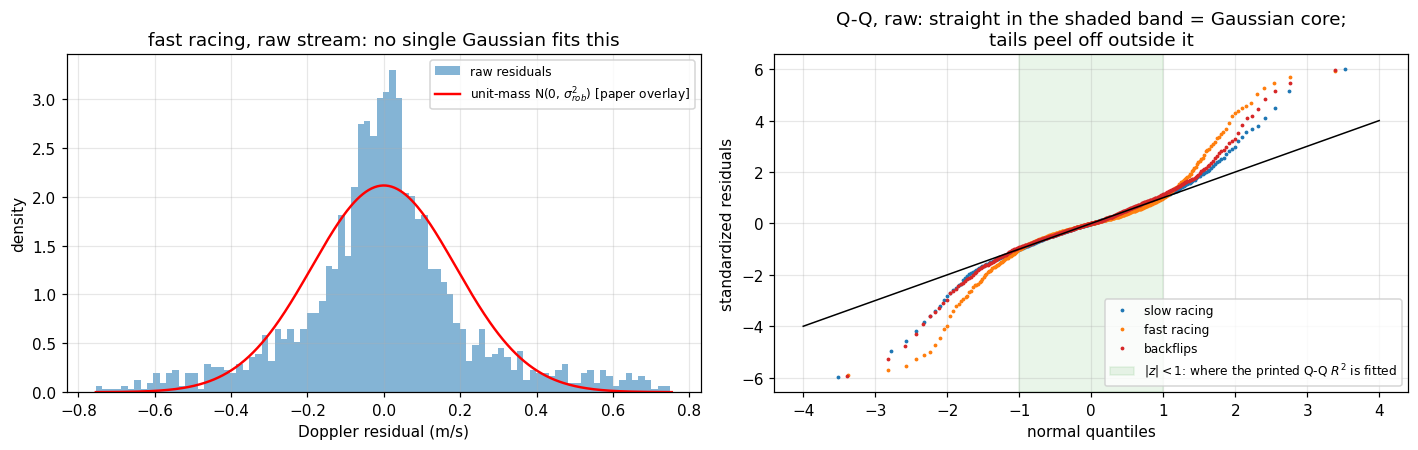

In [4]:
# Rung 0, the raw stream: is the Doppler noise Gaussian? No.
d = D['fast_racing_best_velocity']
rc = d['r'] - np.median(d['r'])
s_mad = robust_sigma(rc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
lim = 4 * s_mad
core = rc[np.abs(rc) < lim]
axes[0].hist(core, bins=90, density=True, alpha=0.55, label='raw residuals')
xg = np.linspace(-lim, lim, 400)
axes[0].plot(xg, sp_stats.norm.pdf(xg, 0, s_mad), 'r-', lw=1.6,
             label='unit-mass N(0, $\\sigma_{rob}^2$) [paper overlay]')
axes[0].set_xlabel('Doppler residual (m/s)'); axes[0].set_ylabel('density')
axes[0].set_title('fast racing, raw stream: no single Gaussian fits this')
axes[0].legend(fontsize=8)

for key in BAG_KEYS:
    dd = D[key]
    sz = robust_sigma(dd['r']); m = np.median(dd['r'])
    z = (dd['r'] - m) / sz
    zc = z[np.abs(z) < 6]
    (osm, osr), _ = sp_stats.probplot(zc, dist='norm', plot=None)
    ii = np.unique(np.linspace(0, len(osm) - 1, 400).astype(int))
    axes[1].plot(osm[ii], osr[ii], '.', ms=3, color=COLOR[key], label=SHORT[key])
axes[1].plot([-4, 4], [-4, 4], 'k-', lw=1)
axes[1].axvspan(-1.0, 1.0, color='tab:green', alpha=0.10,
                label='$|z| < 1$: where the printed Q-Q $R^2$ is fitted')
axes[1].set_xlabel('normal quantiles'); axes[1].set_ylabel('standardized residuals')
axes[1].set_title('Q-Q, raw: straight in the shaded band = Gaussian core;\n'
                  'tails peel off outside it')
axes[1].legend(fontsize=8, loc='lower right')
fig.tight_layout()

for key in BAG_KEYS:
    dd = D[key]
    z = (dd['r'] - np.median(dd['r'])) / robust_sigma(dd['r'])
    zc = z[np.abs(z) < 1.0]
    (osm, osr), (slope, icept, rval) = sp_stats.probplot(zc, dist='norm', plot=None)
    print(f'{SHORT[key]}: Q-Q R^2 inside |z|<1 (~{100*np.mean(np.abs(z)<1.0):.0f}% '
          f'of points): {rval**2:.4f}')
print('The central band is Gaussian-shaped on every flight; everything beyond it is')
print('not. The rest of this section finds out what the "everything beyond" is.\n')

print(f"{'bag':<14} {'sigma_rob':>10} {'sigma 1-99%':>12} {'kurtosis':>9} "
      f"{'tail mass':>9} {'quant bin':>10}")
for key in BAG_KEYS:
    d = D[key]
    r = d['r']
    q1, q99 = np.percentile(r, [1, 99])
    s99 = np.std(r[(r >= q1) & (r <= q99)])
    sz = robust_sigma(r)
    kurt = sp_stats.kurtosis(r)
    fr3 = np.mean(np.abs(r - np.median(r)) > 3 * sz)
    vals = np.sort(np.unique(np.concatenate([np.asarray(f.velocities)
                                             for f in d['radar']])))
    dv = np.diff(vals); dv = dv[dv > 1e-6]
    print(f"{SHORT[key]:<14} {sz:>10.3f} {s99:>12.3f} {kurt:>9.1f} "
          f"{100*fr3:>8.1f}% {np.median(dv):>10.3f}")
print('\npaper: sigma_rob 0.097 / 0.189 / 0.354, 1-99% sigma 0.191 / 0.573 / 0.460,')
print('kurtosis 32.0 / 6.5 / 6.8, tail mass 8.6 / 17.8 / 6.6 %, bin 0.049 m/s')

<font color='red'>zero-mean, symmetrishe, exponentiell abnehmende streuung - wichtiges für bayesian filter da reicht eigentlich schon. exakte gaussian discovery story darf trotzdem in report</font>

### S1: separate the aliased from the clean returns

Aliased returns are a second population, treated separately from here on out. Their on-chip bearing was
computed from the wrapped velocity and cannot be repaired downstream (TDM
*angle-Doppler coupling*: Bechter et al., MWCL 2017; Grebner et al., MWCL 2022), increasing residual variance. But their Doppler still carries speed information, so the deployment down-weights them by a measured constant (section 5).

S1 clean (non-aliased population):
  bag                 n  of pop.  sigma_rob tail mass  QQ R2 |z|<3
  slow racing      3348     100%      0.094      7.9%       0.9944
  fast racing      1656     100%      0.138     12.6%       0.9889
  backflips        1256     100%      0.279      6.8%       0.9958
S1 ALIASED population (separated, not deleted):
  bag                 n  of pop.  sigma_rob tail mass  QQ R2 |z|<3
  slow racing        68     100%      0.620     23.5%       0.8777
  fast racing       513     100%      0.718      4.5%       0.9883
  backflips         764     100%      0.524      2.2%       0.9972

The aliased population is near-Gaussian in its own right but WIDER, and
it carries a disproportionate share of the pooled fourth moment:
  slow racing   too few aliased returns to characterize (68)
  fast racing   sigma 0.72 vs 0.138 m/s (5.2x); 24% of returns carry 42% of the 4th moment
  backflips     sigma 0.52 vs 0.279 m/s (1.9x); 38% of returns carry 32% of the 4th moment


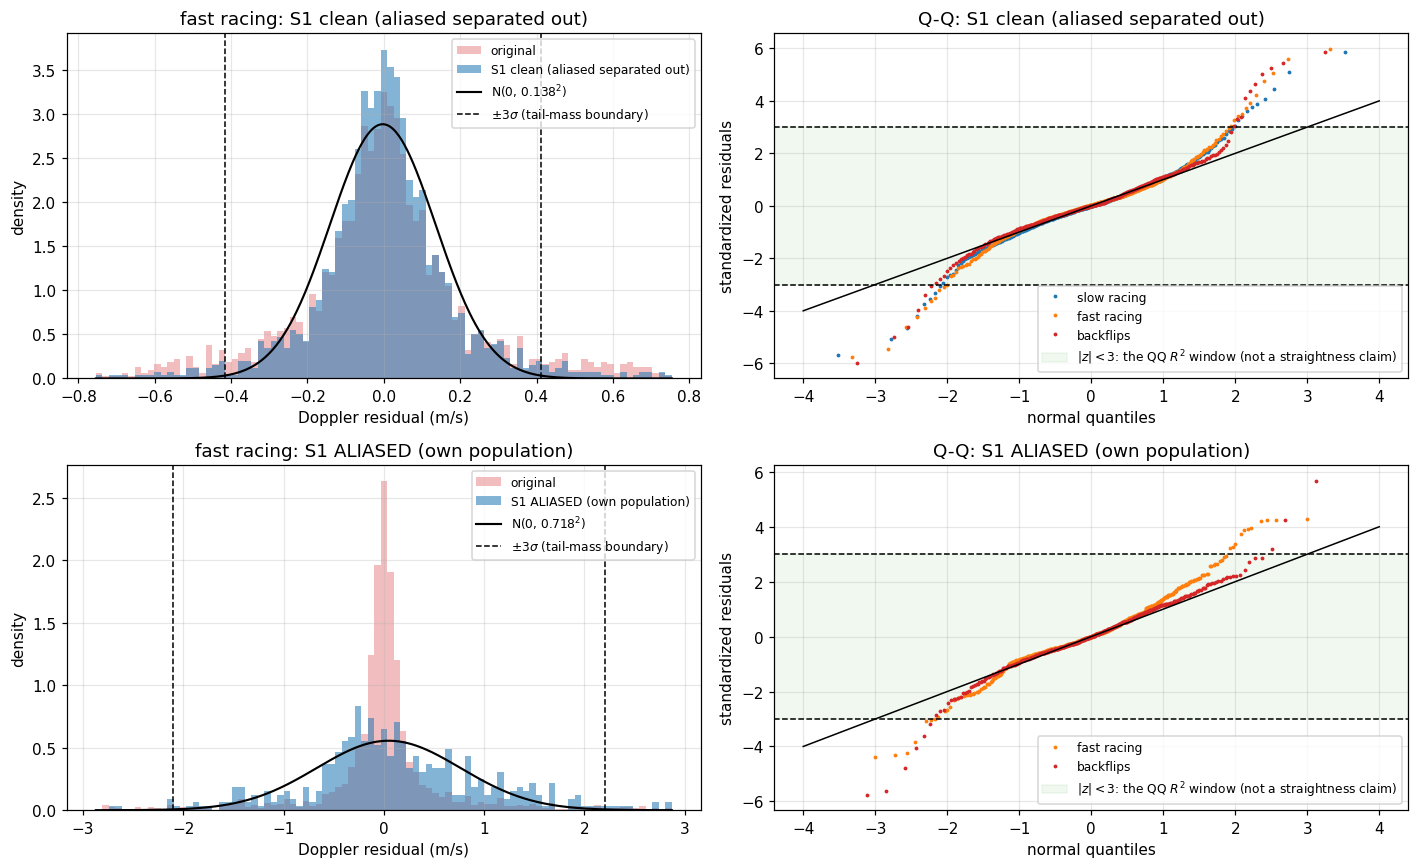

In [5]:
# Rung S1: split the stream into its two populations (nothing is deleted)
def ladder_stats(r):
    z = (r - np.median(r)) / robust_sigma(r)
    zc = z[np.abs(z) < 3]
    (_, _), (_, _, rv) = sp_stats.probplot(zc, dist='norm', plot=None)
    return len(r), robust_sigma(r), 100*np.mean(np.abs(z) > 3), rv**2

def rung_report(name, SEL, BASE):
    # BASE = the population this selection belongs to; percentages are OF THAT
    # POPULATION, never of all returns -- the aliased stream is separated, not
    # deleted, so it keeps its own denominator.
    print(f"{name}:")
    print(f"  {'bag':<14} {'n':>6} {'of pop.':>8} {'sigma_rob':>10} {'tail mass':>9} {'QQ R2 |z|<3':>12}")
    for key in BAG_KEYS:
        d = D[key]
        n, sz, f3, r2 = ladder_stats(d['r'][SEL[key]])
        print(f"  {SHORT[key]:<14} {n:>6d} {100*n/max(BASE[key].sum(),1):>7.0f}% "
              f"{sz:>10.3f} {f3:>8.1f}% {r2:>12.4f}")

def rung_plot2(sels, bgs, titles):
    """Two rows (clean / aliased), each: fast-racing histogram of the row's
    population (background = the same population before this rung) and the
    all-bags Q-Q.  Bags with < 100 points in a population are skipped (slow
    racing has only ~68 aliased returns)."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    dk = 'fast_racing_best_velocity'
    for row, (SEL, BG, title) in enumerate(zip(sels, bgs, titles)):
        d = D[dk]
        rr = d['r'] - np.median(d['r'])
        bg = rr[BG[dk]]; fg = rr[SEL[dk]]
        ax = axes[row, 0]
        lim = 4 * max(robust_sigma(fg), robust_sigma(bg))
        bins = np.linspace(-lim, lim, 90)
        ax.hist(bg[np.abs(bg) < lim], bins=bins, density=True, alpha=0.30,
                color='tab:red', label='original')
        ax.hist(fg[np.abs(fg) < lim], bins=bins, density=True, alpha=0.55,
                color='tab:blue', label=title)
        sz = robust_sigma(fg)
        xg = np.linspace(-lim, lim, 400)
        ax.plot(xg, sp_stats.norm.pdf(xg, np.median(fg), sz), 'k-', lw=1.4,
                label=f'N(0, {sz:.3f}$^2$)')
        for sgn in (-1, 1):
            ax.axvline(np.median(fg) + sgn * 3 * sz, color='k', ls='--', lw=1.0,
                       label='$\\pm 3\\sigma$ (tail-mass boundary)' if sgn > 0 else None)
        ax.set_xlabel('Doppler residual (m/s)'); ax.set_ylabel('density')
        ax.set_title(f'fast racing: {title}')
        ax.legend(fontsize=8)
        ax = axes[row, 1]
        for key in BAG_KEYS:
            dd = D[key]
            rb = (dd['r'] - np.median(dd['r']))[SEL[key]]
            if len(rb) < 100:
                continue
            z = (rb - np.median(rb)) / robust_sigma(rb)
            zc = z[np.abs(z) < 6]
            (osm, osr), _ = sp_stats.probplot(zc, dist='norm', plot=None)
            ii = np.unique(np.linspace(0, len(osm) - 1, 400).astype(int))
            ax.plot(osm[ii], osr[ii], '.', ms=3, color=COLOR[key], label=SHORT[key])
        ax.plot([-4, 4], [-4, 4], 'k-', lw=1)
        ax.axhspan(-3, 3, color='tab:green', alpha=0.07, zorder=0,
                   label='$|z| < 3$: the QQ $R^2$ window (not a straightness claim)')
        for sgn in (-1, 1):
            ax.axhline(sgn * 3, color='k', ls='--', lw=1.0)
        ax.set_xlabel('normal quantiles'); ax.set_ylabel('standardized residuals')
        ax.set_title(f'Q-Q: {title}')
        ax.legend(fontsize=8, loc='lower right')
    fig.tight_layout()

S0_ALL = {key: np.ones(len(D[key]['r']), bool) for key in BAG_KEYS}
SEL1 = {key: ~D[key]['aliased'] for key in BAG_KEYS}
SEL1A = {key: D[key]['aliased'] for key in BAG_KEYS}
rung_report('S1 clean (non-aliased population)', SEL1, SEL1)
rung_report('S1 ALIASED population (separated, not deleted)', SEL1A, SEL1A)
print()
print('The aliased population is near-Gaussian in its own right but WIDER, and')
print('it carries a disproportionate share of the pooled fourth moment:')
for key in BAG_KEYS:
    d = D[key]
    rr = d['r'] - np.median(d['r'])
    al = d['aliased']
    if al.sum() < 100:
        print(f'  {SHORT[key]:<13} too few aliased returns to characterize ({al.sum()})')
        continue
    p = al.mean()
    m4 = (1 - p) * np.mean(rr[~al]**4) + p * np.mean(rr[al]**4)
    print(f'  {SHORT[key]:<13} sigma {robust_sigma(rr[al]):.2f} vs '
          f'{robust_sigma(rr[~al]):.3f} m/s '
          f'({robust_sigma(rr[al])/robust_sigma(rr[~al]):.1f}x); '
          f'{100*p:.0f}% of returns carry '
          f'{100*p*np.mean(rr[al]**4)/m4:.0f}% of the 4th moment')
rung_plot2([SEL1, SEL1A], [S0_ALL, S0_ALL],
           ['S1 clean (aliased separated out)', 'S1 ALIASED (own population)'])

### S2: remove what the consensus rejects, and what it cannot vet

RANSAC is introduced to reject outliers. It needs 5 returns to form a consensus rejection, so sparser frames are discarded entirely in this characterization, but not in deployment. Its threshold is derived in section 3. Frames with fewer than five
returns leave no redundancy (three returns determine a 3-DoF ego-velocity
exactly), so the consensus cannot vet them: deployed, they bypass the prefilter
and Huber is their only protection. Removing them does nothing to the
distribution -- $\sigma$ moves by at most $+0.005$ m/s, the wrong way, on all
three bags -- and it is not counted as a tail mechanism. 

S2 clean   = S1 clean minus thin-frame points:
  bag                 n  of pop.  sigma_rob tail mass  QQ R2 |z|<3
  slow racing      3308      99%      0.095      7.8%       0.9948
  fast racing      1600      97%      0.143     12.4%       0.9883
  backflips        1209      96%      0.283      6.9%       0.9958
S3 clean   = S2 clean minus consensus rejects:
  bag                 n  of pop.  sigma_rob tail mass  QQ R2 |z|<3
  slow racing      3019      90%      0.086      2.8%       0.9967
  fast racing      1292      78%      0.113      5.3%       0.9947
  backflips         973      77%      0.244      2.0%       0.9972
S3 ALIASED = aliased minus thin frames and consensus rejects:
  bag                 n  of pop.  sigma_rob tail mass  QQ R2 |z|<3
  slow racing        26      38%      0.114     11.5%       0.9448
  fast racing       269      52%      0.461      5.9%       0.9827
  backflips         420      55%      0.426      1.9%       0.9918


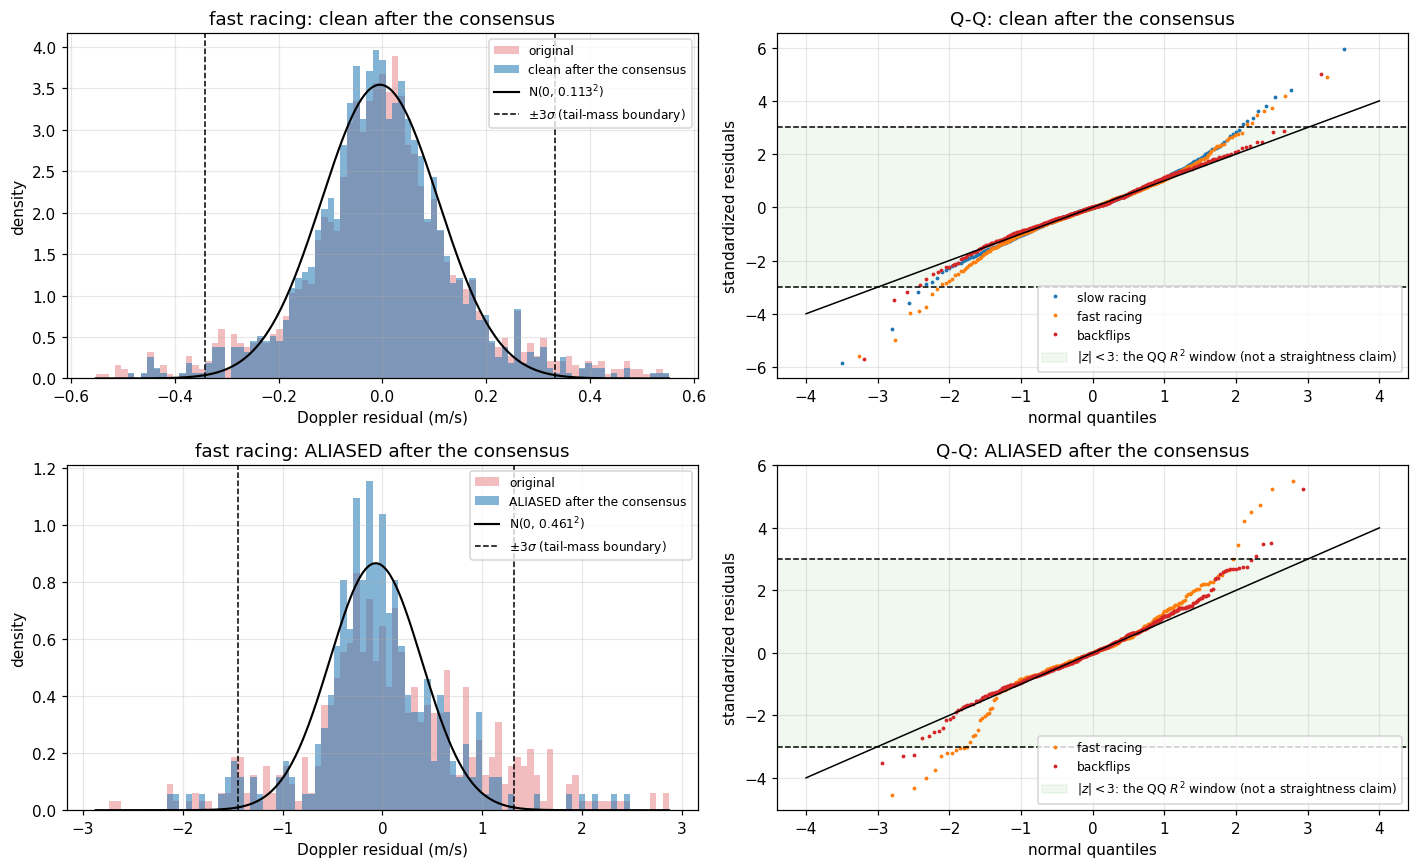

In [6]:
# Rung S2, both sub-steps and both populations: drop thin-frame points, then
# the consensus rejects.  S3_SEL (clean) is what the cells below consume; the
# same treatment applied to the ALIASED population is shown alongside, because
# that population is separated, not deleted.
SEL2, SEL2A = {}, {}
for key in BAG_KEYS:
    d = D[key]
    thin = np.array([d['radar'][i].num_points() < 5 for i in d['fi']])
    SEL2[key] = SEL1[key] & ~thin
    SEL2A[key] = SEL1A[key] & ~thin
S3_SEL, S3A_SEL = {}, {}
for key in BAG_KEYS:
    d = D[key]
    ok = np.ones(len(d['r']), bool)
    for i, m in masks[key].items():
        sel = d['fi'] == i
        for j in np.where(sel)[0]:
            if d['pi'][j] < len(m):
                ok[j] = m[d['pi'][j]]
    S3_SEL[key] = SEL2[key] & ok
    S3A_SEL[key] = SEL2A[key] & ok
rung_report('S2 clean   = S1 clean minus thin-frame points', SEL2, SEL1)
rung_report('S3 clean   = S2 clean minus consensus rejects', S3_SEL, SEL1)
rung_report('S3 ALIASED = aliased minus thin frames and consensus rejects', S3A_SEL, SEL1A)
rung_plot2([S3_SEL, S3A_SEL], [SEL1, SEL1A],
           ['clean after the consensus', 'ALIASED after the consensus'])

  bag           variant                   of clean  sigma_rob tail mass    QQ R2
  slow racing   S2 (before consensus)          99%      0.095      7.8%   0.9948
  slow racing   null: random deletion          90%      0.094      7.4%   0.9950
  slow racing   S3 = RANSAC consensus          90%      0.086      2.8%   0.9967
  slow racing   null: oracle |r| cut           90%      0.084      1.8%   0.9969

  fast racing   S2 (before consensus)          97%      0.143     12.4%   0.9883
  fast racing   null: random deletion          78%      0.124      9.9%   0.9902
  fast racing   S3 = RANSAC consensus          78%      0.113      5.3%   0.9947
  fast racing   null: oracle |r| cut           78%      0.106      2.7%   0.9970

  backflips     S2 (before consensus)          96%      0.283      6.9%   0.9958
  backflips     null: random deletion          77%      0.256      5.4%   0.9976
  backflips     S3 = RANSAC consensus          77%      0.244      2.0%   0.9972
  backflips     null: orac

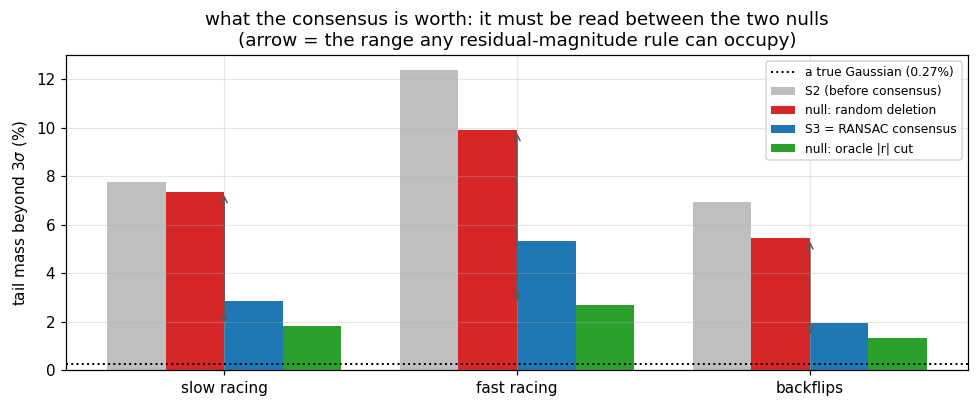

In [7]:
# Is the consensus rung discovery, or just a residual cut?  A consensus
# inlier test IS a residual test (against a per-frame fitted ego-velocity,
# not ground truth), and any procedure that deletes large-residual points
# makes the remainder look more Gaussian.  So it is bracketed by two controls
# that delete the SAME number of points per frame, starting from S2: RANDOM
# deletion (no information about which returns are bad = the floor any
# thinning reaches) and an ORACLE cut deleting the largest |r| against MoCap
# through the forward model (the ceiling of the per-frame, budget-matched
# family of residual-magnitude rules -- not of every |r|-based method: a
# globally-budgeted cut reaches lower still).
def _qq_r2(x, zmax=3.0):
    z = (x - np.median(x)) / robust_sigma(x)
    zc = z[np.abs(z) < zmax]
    (_, _), (_, _, rv) = sp_stats.probplot(zc, dist='norm', plot=None)
    return rv ** 2

rng_ctrl = np.random.default_rng(0)
# percentages are of the CLEAN population (the stream the consensus acts on);
# the aliased population is separated, not part of this bracket.
print(f"  {'bag':<13} {'variant':<24} {'of clean':>9} {'sigma_rob':>10} "
      f"{'tail mass':>9} {'QQ R2':>8}")
CTRL = {}
for key in BAG_KEYS:
    d = D[key]
    S2, S3 = SEL2[key], S3_SEL[key]
    rand_ok = np.ones(len(d['r']), bool)
    oracle_ok = np.ones(len(d['r']), bool)
    for f in np.unique(d['fi']):
        idx = np.flatnonzero((d['fi'] == f) & S2)
        n_drop = int(len(idx) - S3[idx].sum())
        if len(idx) == 0 or n_drop <= 0:
            continue
        rand_ok[rng_ctrl.choice(idx, n_drop, replace=False)] = False
        oracle_ok[idx[np.argsort(-np.abs(d['r'][idx]))[:n_drop]]] = False
    for tag, sel in [('S2 (before consensus)', S2),
                     ('null: random deletion', S2 & rand_ok),
                     ('S3 = RANSAC consensus', S3),
                     ('null: oracle |r| cut', S2 & oracle_ok)]:
        rr = d['r'][sel]
        z = (rr - np.median(rr)) / robust_sigma(rr)
        print(f'  {SHORT[key]:<13} {tag:<24} {100*sel.sum()/SEL1[key].sum():>8.0f}% '
              f'{robust_sigma(rr):>10.3f} {100*np.mean(np.abs(z) > 3):>8.1f}% '
              f'{_qq_r2(rr):>8.4f}')
        CTRL.setdefault(key, {})[tag] = 100 * np.mean(np.abs(z) > 3)
    print()

# The bracket, drawn: random deletion is the floor any same-rate thinning
# reaches, the oracle is the ceiling any residual-magnitude rule could reach,
# and the consensus has to be read between them rather than against zero.
ORDER = ['S2 (before consensus)', 'null: random deletion',
         'S3 = RANSAC consensus', 'null: oracle |r| cut']
FACE = ['0.75', 'tab:red', 'tab:blue', 'tab:green']
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(BAG_KEYS)); w = 0.2
for i, (tag, c) in enumerate(zip(ORDER, FACE)):
    ax.bar(x + (i - 1.5) * w, [CTRL[k][tag] for k in BAG_KEYS], w,
           color=c, label=tag)
for i, k in enumerate(BAG_KEYS):
    ax.annotate('', xy=(i, CTRL[k][ORDER[3]]), xytext=(i, CTRL[k][ORDER[1]]),
                arrowprops=dict(arrowstyle='<->', color='0.35', lw=1.0))
ax.axhline(100 * 2 * (1 - sp_stats.norm.cdf(3)), color='k', ls=':', lw=1.3,
           label='a true Gaussian (0.27%)')
ax.set_xticks(x, [SHORT[k] for k in BAG_KEYS])
ax.set_ylabel('tail mass beyond $3\\sigma$ (%)')
ax.set_title('what the consensus is worth: it must be read between the two nulls\n'
             '(arrow = the range any residual-magnitude rule can occupy)')
ax.legend(fontsize=8)
fig.tight_layout()

Tail mass reduces significantly through the frontend, and the oracle cut proves that it is fairly close to optimal

### How Gaussian is each stream, and what does the variance model leave?

The cell below sweeps the tail-mass ratio over thresholds rather than picking
one: the fraction of returns beyond $k\sigma$, divided by what a true normal
gives (1.0 = Gaussian there), for three streams per flight -- one global
$\sigma$ (no model), the measured per-return law $\sigma_j$ (derived in section 4) on the
clean stream, and the same law on the S3 stream the solver actually consumes.
On the whitened residual it also fits a two-component Gaussian mixture (a
*description* of what the law leaves, not a deployed model -- its parameters do
not transfer across flights, `worklog/2026-08-10_audit-round-3.md`).

stream                                      1.0s    1.5s    2.0s    3.0s
a true normal gives                        31.73   13.36    4.55    0.27
-----------------------------------------------------------------------------------------
slow racing, S1 clean, one global sigma    35.04   20.94   13.47    7.92
   ratio to Gaussian                         1.1     1.6     3.0    29.3
slow racing, S1 clean, law sigma_j         33.45   15.65    8.21    4.90
   ratio to Gaussian                         1.1     1.2     1.8    18.1
slow racing, S3 deployed, law sigma_j      32.56   12.92    4.64    0.56
   ratio to Gaussian                         1.0     1.0     1.0     2.1

fast racing, S1 clean, one global sigma    36.23   24.34   18.66   12.56
   ratio to Gaussian                         1.1     1.8     4.1    46.5
fast racing, S1 clean, law sigma_j         35.02   18.78   12.68    9.18
   ratio to Gaussian                         1.1     1.4     2.8    34.0
fast racing, S3 deployed, law sig

backflips, S1 clean, one global sigma      34.63   17.99   10.59    6.85
   ratio to Gaussian                         1.1     1.3     2.3    25.4
backflips, S1 clean, law sigma_j           34.87   17.68   10.03    5.02
   ratio to Gaussian                         1.1     1.3     2.2    18.6
backflips, S3 deployed, law sigma_j        33.81   16.86    7.30    1.64
   ratio to Gaussian                         1.1     1.3     1.6     6.1

two-component mixture fit on the whitened residual, per flight:
  bag           sigma(w) rob  core mass  sigma_core  sigma_wide   ratio  3s ratio, ABS
  slow racing           0.86        94%        0.81        8.50   10.5x            16x
  fast racing           1.03        88%        0.93       10.35   11.1x            35x
  backflips             1.84        91%        1.76        9.69    5.5x            55x


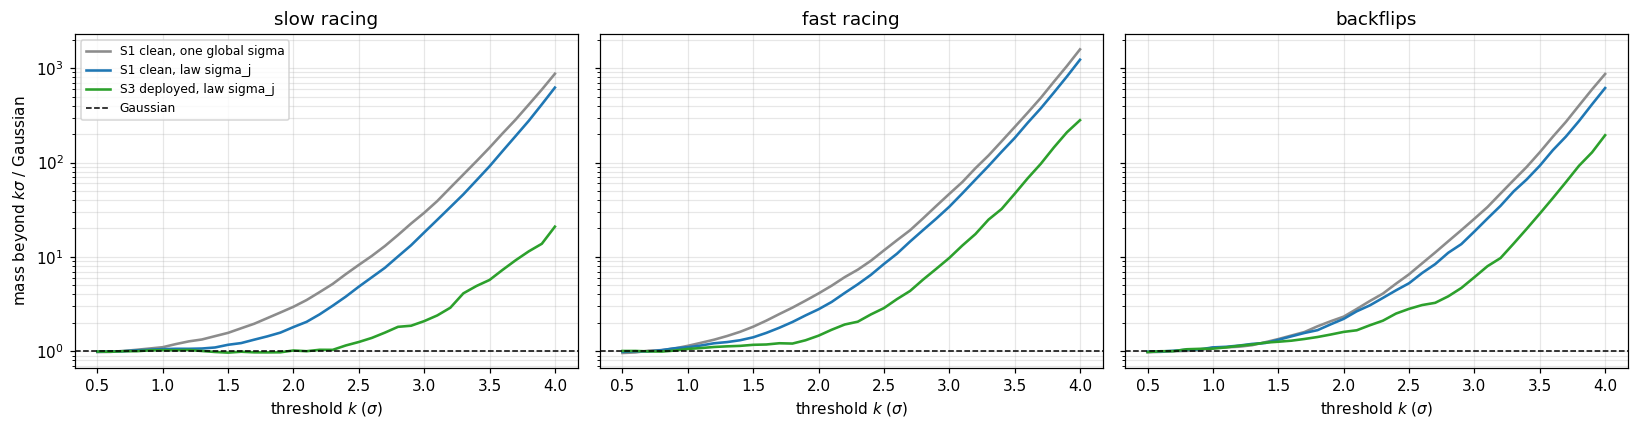

In [8]:
# Tail-mass ratios vs a true normal and the mixture fit -- measurements only;
# what and why is in the cell above, the reading below.
S0_LAW, COEF_LAW = 0.0811, 0.02618        # ARRAY law, characterize_shape_contradiction --block deploy
THR = [1.0, 1.5, 2.0, 3.0]
g_exp = [100 * 2 * (1 - sp_stats.norm.cdf(t)) for t in THR]

def _exceed(z):
    return [100 * np.mean(np.abs(z) > t) for t in THR]

def _std(x):
    return (x - np.median(x)) / robust_sigma(x)

def mixture2(w, iters=500):
    """Zero-mean two-component Gaussian mixture by EM (deterministic init from
    the robust sigma).  Fitted on the ABSOLUTE whitened residual r/sigma_j, so
    sigma_core doubles as the law's calibration factor."""
    w = np.asarray(w, float); w = w[np.isfinite(w)]
    s1, s2, p = robust_sigma(w), 5 * robust_sigma(w), 0.9
    for _ in range(iters):
        a = p * np.exp(-0.5 * (w / s1) ** 2) / s1
        b = (1 - p) * np.exp(-0.5 * (w / s2) ** 2) / s2
        g = a / np.maximum(a + b, 1e-300)
        p = g.mean()
        s1 = np.sqrt(max(np.sum(g * w ** 2) / max(np.sum(g), 1e-12), 1e-12))
        s2 = np.sqrt(max(np.sum((1 - g) * w ** 2) / max(np.sum(1 - g), 1e-12), 1e-12))
    return p, s1, s2

print(f"{'stream':<40} " + ' '.join(f'{t:>6.1f}s' for t in THR))
print(f"{'a true normal gives':<40} " + ' '.join(f'{v:>7.2f}' for v in g_exp))
print('-' * 40 + '-' * 49)
MIX, ZCURVES = {}, {}
for key in BAG_KEYS:
    d = D[key]
    rr = d['r'] - np.median(d['r'])
    cl = ~d['aliased']
    # per-return sigma from the full measured law: q_j = |v| sin(theta)/cos(phi)
    q = np.empty(len(rr))
    v_i = interp1d(d['st_t'], np.array([s.velocity for s in d['states']]), axis=0,
                   kind='linear', bounds_error=False, fill_value='extrapolate')
    q_i = interp1d(d['st_t'], np.array([s.orientation for s in d['states']]), axis=0,
                   kind='linear', bounds_error=False, fill_value='extrapolate')
    for f in np.unique(d['fi']):
        m = d['fi'] == f
        tf = d['radar'][int(f)].timestamp + RADAR_OFF
        v_b = quat_to_rotation_matrix(q_i(tf)).T @ v_i(tf)
        nv = max(np.linalg.norm(v_b), 1e-6)
        P = np.asarray(d['radar'][int(f)].positions, float)[d['pi'][m]]
        s_j = P / np.maximum(np.linalg.norm(P, axis=1), 1e-6)[:, None]   # sensor frame
        u_b = (R_BS @ s_j.T).T
        sin_t = np.sqrt(np.clip(1 - (u_b @ v_b / nv) ** 2, 0, 1))
        q[m] = nv * sin_t / np.maximum(s_j[:, 0], 0.15)                  # /cos(phi)
    sig_j = np.sqrt(S0_LAW ** 2 + (COEF_LAW * q) ** 2)
    # the three streams
    z_glob = _std(rr[cl])
    w_cl = rr[cl] / sig_j[cl]                       # ABSOLUTE whitened residual
    w_s3 = rr[S3_SEL[key]] / sig_j[S3_SEL[key]]     # ... on the deployed stream
    abs3 = 100 * np.mean(np.abs(w_cl - np.median(w_cl)) > 3) / g_exp[3]
    MIX[key] = (robust_sigma(w_cl), abs3) + mixture2(w_cl)
    # grey vs blue = SAME stream, only the scaling differs (one global sigma
    # vs each return's own law sigma_j): that gap is the heteroscedasticity.
    # blue vs green = the front end (S1 clean vs the deployed S3 stream).
    ZCURVES[key] = [(z_glob, 'S1 clean, one global sigma', '0.55'),
                    (_std(w_cl), 'S1 clean, law sigma_j', 'tab:blue'),
                    (_std(w_s3), 'S3 deployed, law sigma_j', 'tab:green')]
    for z, tag, _c in ZCURVES[key]:
        e = _exceed(z)
        print(f'{SHORT[key] + ", " + tag:<40} ' + ' '.join(f'{v:>7.2f}' for v in e))
        print(f'{"   ratio to Gaussian":<40} '
              + ' '.join(f'{v / gg:>7.1f}' for v, gg in zip(e, g_exp)))
    print()

print('two-component mixture fit on the whitened residual, per flight:')
print(f"  {'bag':<13} {'sigma(w) rob':>12} {'core mass':>10} {'sigma_core':>11} "
      f"{'sigma_wide':>11} {'ratio':>7} {'3s ratio, ABS':>14}")
for key in BAG_KEYS:
    sw, a3, p, s1, s2 = MIX[key]
    print(f'  {SHORT[key]:<13} {sw:>12.2f} {100 * p:>9.0f}% {s1:>11.2f} '
          f'{s2:>11.2f} {s2 / s1:>6.1f}x {a3:>13.0f}x')
# the same three streams as continuous curves: where each departs the
# Gaussian line is visible directly, instead of being read off one threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
tg = np.linspace(0.5, 4.0, 36)
gexp_g = 2 * (1 - sp_stats.norm.cdf(tg))
for ax, key in zip(axes, BAG_KEYS):
    for z, nm, c in ZCURVES[key]:
        ratio = [np.mean(np.abs(z) > t) / g for t, g in zip(tg, gexp_g)]
        ax.plot(tg, ratio, color=c, lw=1.7, label=nm)
    ax.axhline(1.0, color='k', lw=1.0, ls='--',
               label='Gaussian' if key == BAG_KEYS[0] else None)
    ax.set_yscale('log')
    ax.set_xlabel('threshold $k$ ($\\sigma$)')
    ax.set_title(SHORT[key])
    ax.grid(alpha=0.3, which='both')
axes[0].set_ylabel('mass beyond $k\\sigma$ / Gaussian')
axes[0].legend(fontsize=8, loc='upper left')
fig.tight_layout()

**Finding (most of the tail is structure; a remainder is not).**

- **Two populations** ( S1): the aliased returns are near-Gaussian in their
  own right but 2-5x wider (fast racing 0.72 against 0.14 m/s)
- **Heteroscedasticity is the grey-vs-blue gap**: those two curves are the
  *same* S1-clean stream, differing only in whether each return is divided by
  one global $\sigma$ or by its own $\sigma_j$ from the measured law basd on speed. The law itself is section 4's subject.
- **The front end is the blue-vs-green gap** (S1 clean vs the deployed S3
  stream): big improvement
- **What neither explains is the companion**: <font color='red'>still an unexplained outlier remainder left. @Lukas ist das akzeptabel, oder gilt die distribution hiermit als non-gaussian? ich bekomme die remainder mit keinem modell erklärt, es sind also mmn wirklich outlier (e.g. multipath reflection). antwort: siehe kommentar eins drüber. zero-mean, symmetrisch, exponentiell abnehmend. das passt so</font>

## 3. Outlier handling (RANSAC & Huber)

bag                      kept    med |r| kept  med |r| rej  rej >3sig
slow racing    3045/3376 (90%)         0.060        0.469 (7.8x)       70%
fast racing    1561/2113 (74%)         0.093        0.580 (6.2x)       51%
backflips      1393/1969 (71%)         0.195        0.459 (2.4x)       17%

The aggregate is the real validation: rejected points carry a several-fold
higher median GT residual than kept points (strongest on racing; weaker on
backflips, where the whole frame is noisy and sigma_rob is already 0.354 so
fewer rejections clear the 3-sigma bar). A per-frame consensus can never
match GT labels point-for-point: with 0.1-0.35 m/s noise against a 3-DoF
model, borderline points fall on either side.


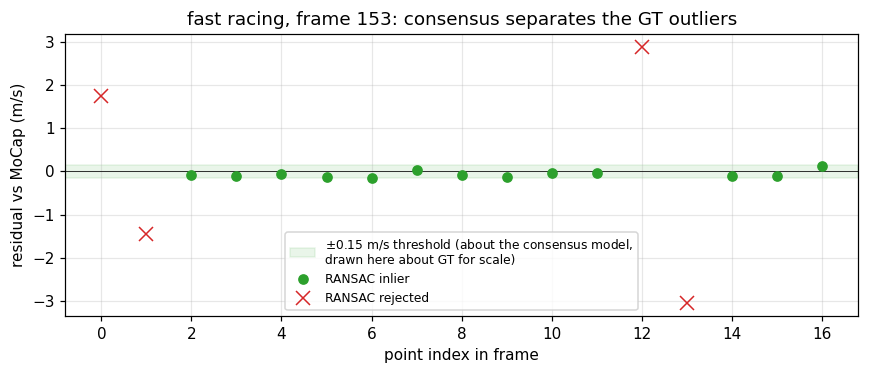

In [9]:
# Deep dive: the deployed RANSAC prefilter (reve-style 3-point ego-velocity
# consensus) in action, copied from validate_live_solver.py
THRESH = 0.15   # solver.yaml radar_ransac_threshold
# IMPORTANT pipeline-order detail (verified in validate_live_solver.py): in
# deployment the prefilter runs on UNWRAPPED Doppler (pre-unwrap happens first).
# Running it on raw wrapped velocities makes the consensus lock onto alias
# populations on the aggressive bags. Here we mirror deployment by feeding the
# GT-unwrapped velocities.
def unwrapped_frame_velocities(d, i):
    v = np.asarray(d['radar'][i].velocities, float).copy()
    sel = d['fi'] == i
    v[d['pi'][sel]] = d['unw'][sel]
    return v

print(f"{'bag':<14} {'kept':>14}   {'med |r| kept':>13} {'med |r| rej':>12} "
      f"{'rej >3sig':>10}")
for key in BAG_KEYS:
    d = D[key]
    s3 = 3 * robust_sigma(d['r'])
    kept = tot = 0
    r_kept, r_rej = [], []
    for i, f in enumerate(d['radar']):
        if f.num_points() < 5:
            continue
        m = masks[key][i]
        kept += int(m.sum()); tot += len(m)
        sel = d['fi'] == i
        for rr, p in zip(d['r'][sel], d['pi'][sel]):
            if p < len(m):
                (r_kept if m[p] else r_rej).append(abs(rr))
    r_kept, r_rej = np.array(r_kept), np.array(r_rej)
    ratio = np.median(r_rej) / max(np.median(r_kept), 1e-9)
    print(f'{SHORT[key]:<14} {kept}/{tot} ({100*kept/tot:.0f}%)   '
          f'{np.median(r_kept):>11.3f}   {np.median(r_rej):>10.3f} ({ratio:.1f}x)  '
          f'{100*np.mean(r_rej > s3):>7.0f}%')
print('\nThe aggregate is the real validation: rejected points carry a several-fold')
print('higher median GT residual than kept points (strongest on racing; weaker on')
print('backflips, where the whole frame is noisy and sigma_rob is already 0.354 so')
print('fewer rejections clear the 3-sigma bar). A per-frame consensus can never')
print('match GT labels point-for-point: with 0.1-0.35 m/s noise against a 3-DoF')
print('model, borderline points fall on either side.')

# one illustrative fast-racing frame: pick the frame with the clearest
# kept/rejected separation in GT residuals (>=3 rejections)
d = D['fast_racing_best_velocity']
best, best_gap = None, -1
for i, m in masks['fast_racing_best_velocity'].items():
    sel = d['fi'] == i
    rr = d['r'][sel]; pp = d['pi'][sel]
    inl = np.array([m[p] for p in pp if p < len(m)])
    if inl.size < 8 or (~inl).sum() < 3:
        continue
    gap = np.median(np.abs(rr[~inl])) - np.median(np.abs(rr[inl]))
    if gap > best_gap:
        best, best_gap = i, gap
sel = d['fi'] == best
m = masks['fast_racing_best_velocity'][best]
rr = d['r'][sel]; pp = d['pi'][sel]
inl = np.array([m[p] if p < len(m) else True for p in pp])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axhline(0, color='k', lw=0.5)
ax.axhspan(-THRESH, THRESH, color='tab:green', alpha=0.10,
           label='$\\pm$0.15 m/s threshold (about the consensus model,\n'
                 'drawn here about GT for scale)')
ax.plot(np.where(inl)[0], rr[inl], 'o', color='tab:green', label='RANSAC inlier')
ax.plot(np.where(~inl)[0], rr[~inl], 'x', ms=9, color='tab:red',
        label='RANSAC rejected')
ax.set_xlabel('point index in frame')
ax.set_ylabel('residual vs MoCap (m/s)')
ax.set_title(f'fast racing, frame {best}: consensus separates the GT outliers')
ax.legend(fontsize=8)
fig.tight_layout()

The prefilter threshold is adopted from the reve baseline (Doer et al.): their
RANSAC accepts a point as an inlier when its Doppler residual against the 3-point
least-squares ego-velocity is below `inlier_thresh` = 0.15 m/s (their shipped
default; source vendored in `analysis/baselines/rio/reve/`). 

    T                       slow racing                        fast racing                          backflips
     kept rej-bad kept-bad byp cons-badkept rej-bad kept-bad byp cons-badkept rej-bad kept-bad byp cons-bad
 0.05     69      27      0.5  1.2      0.4     56      31      8.1 12.7      5.7     56      11      3.4 13.4      2.8
 0.07     79      39      0.6  0.8      0.5     62      37      7.1  9.5      4.9     61      12      3.3 10.4      3.1
 0.10     84      50      1.1  0.4      1.0     68      41      7.2  9.5      5.2     65      14      2.8  7.9      2.8
 0.12     88      62      1.3  0.4      1.2     71      46      6.8  8.2      4.9     68      16      2.5  6.1      2.5
 0.15     90      70      2.0  0.4      1.9     74      52      6.0  6.3      4.5     71      15      3.1  4.9      3.1
 0.20     93      87      2.8  0.4      2.7     77      58      6.2  5.1      5.1     75      18      2.9  2.4      2.8
 0.25     94      92      3.5  0.4      3.5     78      61    

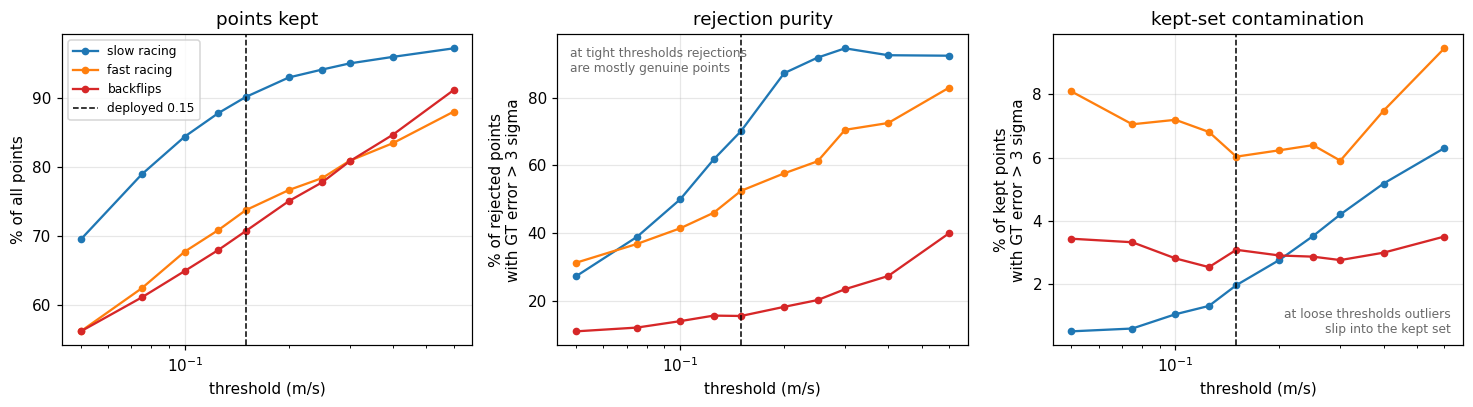

In [10]:
# Deep dive: sweep the consensus inlier band and measure both failure edges
# against ground truth. The 150 sampled 3-point ego-velocity candidates per
# frame do not depend on the threshold, so each frame's candidate residual matrix
# is computed once and inliers are re-counted per threshold (identical to
# re-running the seeded RANSAC at every threshold).
SWEEP_T = np.array([0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.25, 0.30, 0.40, 0.60])
sweep = {}
for key in BAG_KEYS:
    d = D[key]
    rng = np.random.default_rng(0)
    frames = []
    for i, f in enumerate(d['radar']):
        n = f.num_points()
        if n < 5:
            continue
        P = np.asarray(f.positions, float)
        v = np.asarray(f.velocities, float).copy()
        sel = d['fi'] == i
        v[d['pi'][sel]] = d['unw'][sel]          # deployment order: unwrap first
        Hn = P / np.maximum(np.linalg.norm(P, axis=1, keepdims=True), 1e-6)
        cand = []
        for _ in range(150):
            i3 = rng.choice(n, 3, replace=False)
            try:
                cand.append(np.linalg.solve(Hn[i3], v[i3]))
            except np.linalg.LinAlgError:
                continue
        if not cand:
            continue
        Rm = np.abs(Hn @ np.array(cand).T - v[:, None]).T
        r_gt = np.full(n, np.nan)
        r_gt[d['pi'][sel]] = np.abs(d['r'][sel])
        frames.append((Rm, r_gt))
    s3 = 3 * robust_sigma(d['r'])
    rows = []
    for T in SWEEP_T:
        kept = tot = n_byp = 0
        rk, rr, rk_cons = [], [], []
        for Rm, r_gt in frames:
            inl = Rm < T
            best = inl[np.argmax(inl.sum(axis=1))]
            bypassed = best.sum() < 5
            if bypassed:                          # deployed bypass: keep the frame
                best = np.ones(len(r_gt), bool)
                n_byp += 1
            kept += int(best.sum()); tot += len(best)
            ok = np.isfinite(r_gt)
            rk.extend(r_gt[best & ok]); rr.extend(r_gt[(~best) & ok])
            if not bypassed:
                rk_cons.extend(r_gt[best & ok])
        rk, rr, rk_cons = np.array(rk), np.array(rr), np.array(rk_cons)
        rows.append((100 * kept / tot,
                     100 * np.mean(rr > s3) if len(rr) else np.nan,
                     100 * np.mean(rk > s3) if len(rk) else np.nan,
                     100 * n_byp / len(frames),
                     100 * np.mean(rk_cons > s3) if len(rk_cons) else np.nan))
    sweep[key] = np.array(rows)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharex=True)
panels = [('points kept', '% of all points'),
          ('rejection purity', '% of rejected points\nwith GT error > 3 sigma'),
          ('kept-set contamination', '% of kept points\nwith GT error > 3 sigma')]
for col, (ax, (ti, yl)) in enumerate(zip(axes, panels)):
    for key in BAG_KEYS:
        ax.plot(SWEEP_T, sweep[key][:, col], '-o', ms=4, color=COLOR[key],
                label=SHORT[key])
    ax.axvline(0.15, color='k', lw=1, ls='--',
               label='deployed 0.15' if col == 0 else None)
    ax.set_xscale('log'); ax.set_xlabel('threshold (m/s)')
    ax.set_title(ti); ax.set_ylabel(yl)
axes[0].legend(fontsize=8)
axes[1].text(0.03, 0.96, 'at tight thresholds rejections\nare mostly genuine points',
             transform=axes[1].transAxes, va='top', fontsize=8, color='dimgray')
axes[2].text(0.97, 0.04, 'at loose thresholds outliers\nslip into the kept set',
             transform=axes[2].transAxes, ha='right', fontsize=8, color='dimgray')
fig.tight_layout()


# the numbers the conclusion cell quotes, per threshold and bag:
# kept% | rejected-points-truly-bad% | kept-set contamination% | frame bypass% |
# consensus-passed contamination%
hdr = ' '.join(f'{SHORT[k][:11]:>34}' for k in BAG_KEYS)
print(f"{'T':>5}{hdr}")
sub = 'kept rej-bad kept-bad byp cons-bad'
print(f"{'':>5}" + ''.join(f'{sub:>34}' for _ in BAG_KEYS))
for ti, T in enumerate(SWEEP_T):
    line = f'{T:5.2f}'
    for k in BAG_KEYS:
        r = sweep[k][ti]
        line += (f'  {r[0]:5.0f} {r[1]:7.0f} {r[2]:8.1f} {r[3]:4.1f} {r[4]:8.1f}')
    print(line)


Frames are overdetermined (>3 returns per frame) so a consensus filter can delete returns. the acceptance band sweep does not show any obviously better value, so the original is kept

bag            delta/sigma_S3  raw beyond delta  S3 beyond delta
slow racing             11.6x             2.66%            0.03%
fast racing              8.9x            11.48%            1.55%
backflips                4.1x             7.18%            1.13%

Sanity: delta sits 4.1-11.6x above the post-ladder core (vs 1.345x for a
textbook efficiency kernel) and 20x the 0.049 m/s quantization bin: it
shapes only the tail, never the fit. Same design for the accelerometer
(delta_a = 2.0 m/s^2 vs in-band residual 0.45-1.1 = 1.8-4.4x). Ablation
(measured at the rate-law-era defaults, like the other front-end rows of
notebook 11 ledger): removing Huber is bit-par on slow (it touches 0.03%
of kept points) but costs fast racing drift 1.17 -> 1.45%.


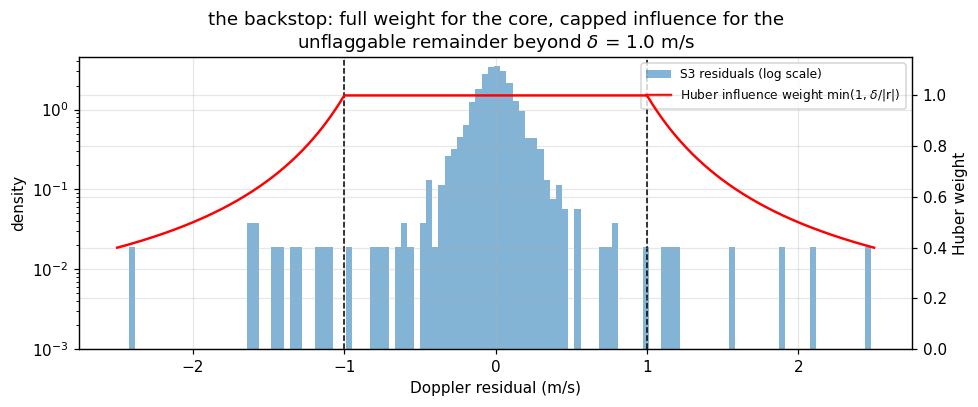

In [11]:
# Huber: the backstop for the unflaggable remainder + a brief parameter sanity
# check. delta = 1.0 m/s is deliberately NOT an efficiency-tuned M-estimator
# (that convention would be delta ~ 1.345 sigma); it is a wide backstop that
# leaves the core strictly quadratic and only caps what the ladder cannot flag.
print(f"{'bag':<14} {'delta/sigma_S3':>14} {'raw beyond delta':>17} {'S3 beyond delta':>16}")
for key in BAG_KEYS:
    d = D[key]
    rr = d['r'] - np.median(d['r'])
    r3 = rr[S3_SEL[key]]
    print(f'{SHORT[key]:<14} {1.0/robust_sigma(r3):>13.1f}x '
          f'{100*np.mean(np.abs(rr) > 1.0):>16.2f}% {100*np.mean(np.abs(r3) > 1.0):>15.2f}%')
print()
print('Sanity: delta sits 4.1-11.6x above the post-ladder core (vs 1.345x for a')
print('textbook efficiency kernel) and 20x the 0.049 m/s quantization bin: it')
print('shapes only the tail, never the fit. Same design for the accelerometer')
print('(delta_a = 2.0 m/s^2 vs in-band residual 0.45-1.1 = 1.8-4.4x). Ablation')
print('(measured at the rate-law-era defaults, like the other front-end rows of')
print('notebook 11 ledger): removing Huber is bit-par on slow (it touches 0.03%')
print('of kept points) but costs fast racing drift 1.17 -> 1.45%.')

d = D['fast_racing_best_velocity']
rr = d['r'] - np.median(d['r'])
r3 = rr[S3_SEL['fast_racing_best_velocity']]
fig, ax = plt.subplots(figsize=(9, 3.8))
lim = 2.5
ax.hist(r3[np.abs(r3) < lim], bins=120, density=True, alpha=0.55,
        label='S3 residuals (log scale)')
ax.set_yscale('log'); ax.set_ylim(1e-3, None)
ax2 = ax.twinx()
xg = np.linspace(-lim, lim, 500)
ax2.plot(xg, np.minimum(1.0, 1.0/np.maximum(np.abs(xg), 1e-9)), 'r-', lw=1.6,
         label='Huber influence weight min(1, $\\delta$/|r|)')
ax2.set_ylim(0, 1.15); ax2.set_ylabel('Huber weight')
ax.axvline(1.0, color='k', ls='--', lw=1); ax.axvline(-1.0, color='k', ls='--', lw=1)
ax.set_xlabel('Doppler residual (m/s)'); ax.set_ylabel('density')
ax.set_title('the backstop: full weight for the core, capped influence for the\n'
             'unflaggable remainder beyond $\\delta$ = 1.0 m/s')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
fig.tight_layout()

<font color='red'>|v \dot u|=d. absolutgeschwindigkeit auf doppler ray projiziert. das ist letztendlich doppler velocity, also geht gleichung auch direkt basiernd auf doppler, nicht abs velocity, dadurch closed-system unabhängig der imu-preintegration, keine abhängigkeit davon, wie genau wir die absolutgeschwindkeit kennen</font>

## 4. The per-return noise law, its mechanism, and the weight it implies

**The statistic.** Within one frame, deviations from the frame's own mean cancel
anything common to every ray -- a shared reference error, a timestamp error, a
scene-wide offset -- so the rescaled deviations
$d_j = (r_j - \bar r_f)/\sqrt{1 - 1/N_f}$ estimate the *per-return* noise
$\sigma_j$ with no contribution from the estimator or the reference's common
mode. Everything below is measured on that statistic, on the clean (non-aliased)
stream -- the first plot below shows why that split is forced: clean noise
responds to dynamics, aliased noise does not.

**Law derivation**

$$ \sigma_j \;=\; \frac{\delta\phi_0}{\sqrt2}\,
   \frac{|\mathbf v|\sin\theta_j}{\cos\phi_j}, \qquad
   \phi_j = \text{angle off boresight}, $$

<details>
<summary><b>Unfold: the derivation, step by step</b></summary>

**Step 1: a direction error becomes a Doppler residual.** The Doppler shift is
physical: the sensor measures the radial velocity along the *true* ray,
$v_\mathrm{meas} = -\mathbf u_\mathrm{true}\cdot\mathbf v$ (plus everything this
derivation is not about: sensor noise, the lever arm). The forward model
predicts with the *reported* ray,
$v_\mathrm{pred} = -\mathbf u_\mathrm{rep}\cdot\mathbf v$. The residual
contributed by the direction error
$\delta\mathbf u = \mathbf u_\mathrm{rep} - \mathbf u_\mathrm{true}$ is
$r_j = \delta\mathbf u\cdot\mathbf v$.

**Step 2: only the transverse velocity couples.** Both rays are unit vectors,
so $\lVert\mathbf u_\mathrm{true} + \delta\mathbf u\rVert = 1$ forces
$\mathbf u_\mathrm{true}\cdot\delta\mathbf u = O(\delta\phi^2)$: to first
order the error is perpendicular to the ray, and to either ray, since the two
differ only by the error itself. Write $\mathbf u$ for
$\mathbf u_\mathrm{true}$ from here on. Split
$\mathbf v = v_\parallel\,\mathbf u + \mathbf v_\perp$ with
$\lVert\mathbf v_\perp\rVert = \lVert\mathbf v\rVert\sin\theta_j$. The radial
part is orthogonal to $\delta\mathbf u$ and drops out of the dot product:
$r_j = \delta\mathbf u\cdot\mathbf v_\perp$.

**Step 3: the $\sqrt2$.** Write the angular size of the error as
$\delta\phi_j$ (an rms over returns) and model its direction as isotropic in
the tangent plane: each of the two components then carries rms
$\delta\phi_j/\sqrt2$, and only the component along $\mathbf v_\perp$ survives
the dot product. Hence $\sigma_j = (\delta\phi_j/\sqrt2)\,\lVert\mathbf v\rVert\sin\theta_j$.

**Step 4: why $\delta\phi_j$ grows off boresight.** A phased array does not
measure angles; the angle FFT bins the **direction cosine** $s_y = \sin\phi$ at
constant precision $\delta s_y$ (the measured lattice below: 64 bins, error
about one bin). Differentiating $s_y = \sin\phi$ gives
$\delta s_y = \cos\phi\cdot\delta\phi$, so a constant direction-cosine error is
the angle error $\delta\phi_j = \delta s_y/\cos\phi_j$. Naming the boresight
value $\delta\phi_0$ (at $\phi = 0$ the two coincide) gives
$\delta\phi_j = \delta\phi_0/\cos\phi_j$; substituting into step 3 yields the
law.

Caveats, and the fit's guard: the perpendicularity in step 2 and the derivative
in step 4 are first order in the error, which is small (~2 deg); the fit
necessarily evaluates $\theta_j$ and $\phi_j$ from the *reported* ray, the
only one available, which moves $\sigma_j$ only at the same second order; and
$1/\cos\phi$ diverges at $\phi = 90^\circ$, so the fit clamps
$\cos\phi \ge 0.15$ (binding on 0.5-1.9 % of returns). The exactly-derived
variant with a constant error on both resolved direction cosines and the third
component fixed by unit norm (the DIRCOS form, notebook 11 section 8) needs no
clamp and fits indistinguishably; the $1/\cos\phi$ form quoted here is its
azimuth-slice simplification.
</details>

**From the law to the fitted form.** The law is the *dynamic* part of a
return's noise; every return additionally carries speed-independent noise
(detection noise, the quantization bin). Independent error sources add in
variance, so with $q_j = \lvert\mathbf v\rvert\sin\theta_j/\cos\phi_j$
collecting the geometry, the form every fit and figure below uses is

$$ \sigma_j^2 \;=\; \sigma_0^2 + (c\,q_j)^2, \qquad
   c = \frac{\delta\phi_0}{\sqrt2}, \qquad q_j = \frac{\lvert\mathbf v\rvert\sin\theta_j}{\cos\phi_j}$$

two parameters: a per-flight floor $\sigma_0$ (the width at $q_j = 0$) and the
one shared coefficient $c$. <font color='red'>One deployment note: the
deployed weights freeze $\sigma_0$ at the racing-derived constant instead of
adapting it per flight, as it varies only by 1.5x across the observed bags
so far; a deployment far outside that envelope would mis-normalize the
weights. This can be upgraded to in-flight calibration.@Lukas wie wichtig ist das? ~3-4Tage arbeit für geringen messbaren effekt, aber wissenschaftlich korrekt. - doesnt matter, its not novel. just put it into future works</font>

| symbol | meaning |
|---|---|
| $\sigma_j$ | predicted Doppler noise (std, m/s) of return $j$ |
| $\delta\phi_j$ | bearing error of return $j$: the angle between the reported and the true ray direction. Not fitted per return; the law models it as $\delta\phi_0/\cos\phi_j$ |
| $\delta\phi_0$ | the single fitted constant: the rms bearing error a boresight ray carries, $\approx 2^\circ$ (one angle-FFT bin, see the mechanism below) |
| $\sigma_0$ | per-flight noise floor: the residual width at $q_j = 0$ (fitted per flight, 0.050/0.073 m/s on racing). Collects the speed-independent error (detection noise, the 0.049 m/s quantization bin) and adds in quadrature: the fitted form is $\sigma_j^2 = \sigma_0^2 + (c\,q_j)^2$ |
| $\lvert\mathbf v\rvert$ | platform speed at the frame's timestamp |
| $\theta_j$ | angle between the ray and the velocity vector (geometry, not an error): only the transverse velocity $\lvert\mathbf v\rvert\sin\theta_j$ can leak a direction error into the Doppler |
| $\phi_j$ | the ray's angle off boresight (geometry): the array's constant direction-cosine error stretches to the angle error $\delta\phi_0/\cos\phi_j$ |
| $\sqrt2$ | the direction error has two components perpendicular to the ray; only the one along the transverse velocity couples, and for an isotropic error the rms projection is $\delta\phi_j/\sqrt2$ |

Competing derived mechanisms
(coherent-window smear, range migration, a body-rate term) were fitted jointly
against the same statistic and excluded -- in particular, given speed, rotation
takes a coefficient of exactly zero, so body rate appears nowhere in the radar
noise model (full contest: notebook 11 section 8 and
`worklog/2026-08-06_shape-contradiction.md`).

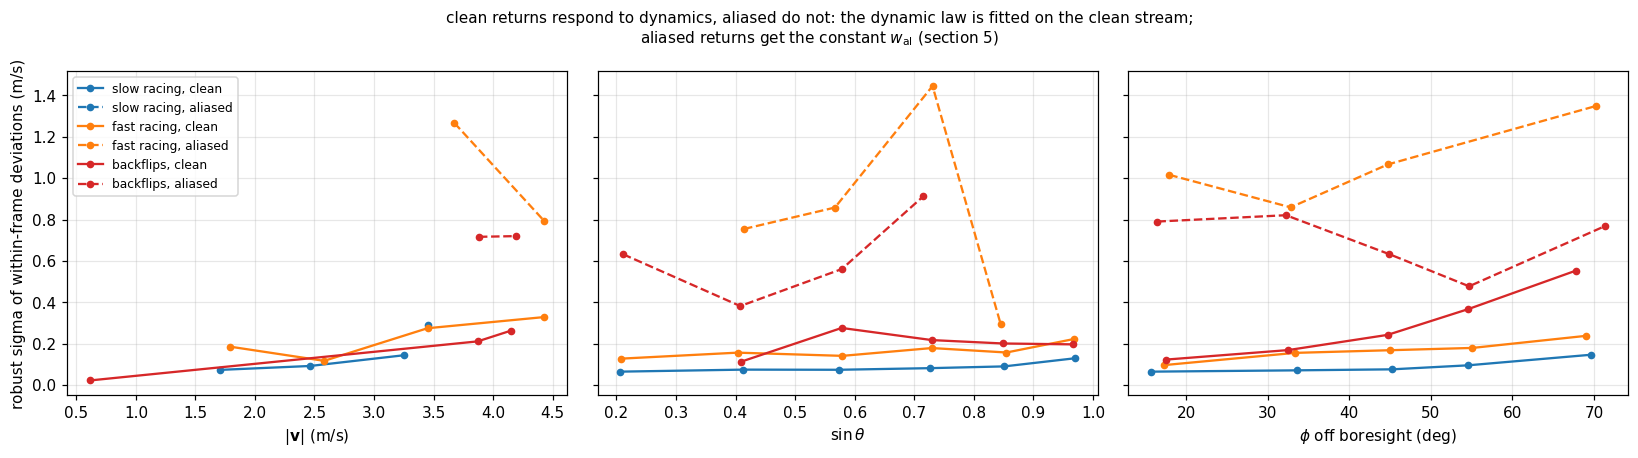

In [12]:
# Why the dynamic law is a clean-return model: within-frame deviations
# (reference-immune, same protocol as the like-for-like table in section 5)
# binned by each law input, per population.  The clean population's noise
# responds to all three inputs; the aliased population sits on a high floor
# with no comparable response (its bearing was computed on-chip from the
# wrapped velocity; section 2).  NOTE: the deployed constant sigma_al = 0.6
# is derived from a DIFFERENT statistic (pooled total width, section 5) and
# is deliberately not drawn here -- mixing the two is the trap section 5's
# finding warns about.
AF_ED = {'v': np.array([0, 1, 2, 3, 4, 5, 7]),
         'sin': np.array([0.0, 0.3, 0.5, 0.65, 0.8, 0.9, 1.0]),
         'phi': np.array([0, 25, 40, 50, 60, 90])}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for key in BAG_KEYS:
    d = D[key]
    clean = ~d['aliased']
    v_i2 = interp1d(d['st_t'], np.array([s.velocity for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False,
                    fill_value='extrapolate')
    q_i2 = interp1d(d['st_t'], np.array([s.orientation for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False,
                    fill_value='extrapolate')
    n_pt = len(d['r'])
    dev = np.full(n_pt, np.nan)
    spd = np.full(n_pt, np.nan)
    sth = np.full(n_pt, np.nan)
    phi = np.full(n_pt, np.nan)
    for f in np.unique(d['fi']):
        mf = d['fi'] == f
        mc = mf & clean
        ma = mf & d['aliased']
        if mc.sum() < 6:
            continue
        fr = d['radar'][int(f)]
        mu = d['r'][mc].mean()
        dev[mc] = (d['r'][mc] - mu) / np.sqrt(1 - 1 / mc.sum())
        dev[ma] = d['r'][ma] - mu
        v_b = quat_to_rotation_matrix(q_i2(fr.timestamp + RADAR_OFF)).T \
            @ v_i2(fr.timestamp + RADAR_OFF)
        nv = max(np.linalg.norm(v_b), 1e-6)
        P = np.asarray(fr.positions, float)[d['pi'][mf]]
        s_j = P / np.maximum(np.linalg.norm(P, axis=1), 1e-6)[:, None]
        u_b = (R_BS @ s_j.T).T
        spd[mf] = nv
        sth[mf] = np.sqrt(np.clip(1 - (u_b @ v_b / nv) ** 2, 0, 1))
        phi[mf] = np.degrees(np.arccos(np.clip(s_j[:, 0], -1, 1)))
    ok = np.isfinite(dev)
    xs = {'v': spd, 'sin': sth, 'phi': phi}
    for ax, (xk, ED) in zip(axes, AF_ED.items()):
        for pop, ls, tag in [(clean, '-', 'clean'),
                             (d['aliased'], '--', 'aliased')]:
            sel = ok & pop
            cen, sig = [], []
            for lo, hi in zip(ED[:-1], ED[1:]):
                m = sel & (xs[xk] >= lo) & (xs[xk] < hi)
                if m.sum() >= 40:
                    cen.append(xs[xk][m].mean())
                    sig.append(robust_sigma(dev[m]))
            if cen:
                ax.plot(cen, sig, ls + 'o', color=COLOR[key], ms=4,
                        label=f'{SHORT[key]}, {tag}' if xk == 'v' else None)
axes[0].set_xlabel('$|\\mathbf{v}|$ (m/s)')
axes[1].set_xlabel('$\\sin\\theta$')
axes[2].set_xlabel('$\\phi$ off boresight (deg)')
axes[0].set_ylabel('robust sigma of within-frame deviations (m/s)')
axes[0].legend(fontsize=8)
fig.suptitle('clean returns respond to dynamics, aliased do not: the dynamic '
             'law is fitted on the clean stream;\naliased returns get the '
             'constant $w_\\mathrm{al}$ (section 5)', fontsize=10)
fig.tight_layout()


slow racing   sigma boresight -> 83 deg: 0.056 -> 0.311 m/s (5.6x)
fast racing   sigma boresight -> 83 deg: 0.076 -> 0.346 m/s (4.6x)
backflips     sigma boresight -> 83 deg: 0.206 -> 0.631 m/s (3.1x)


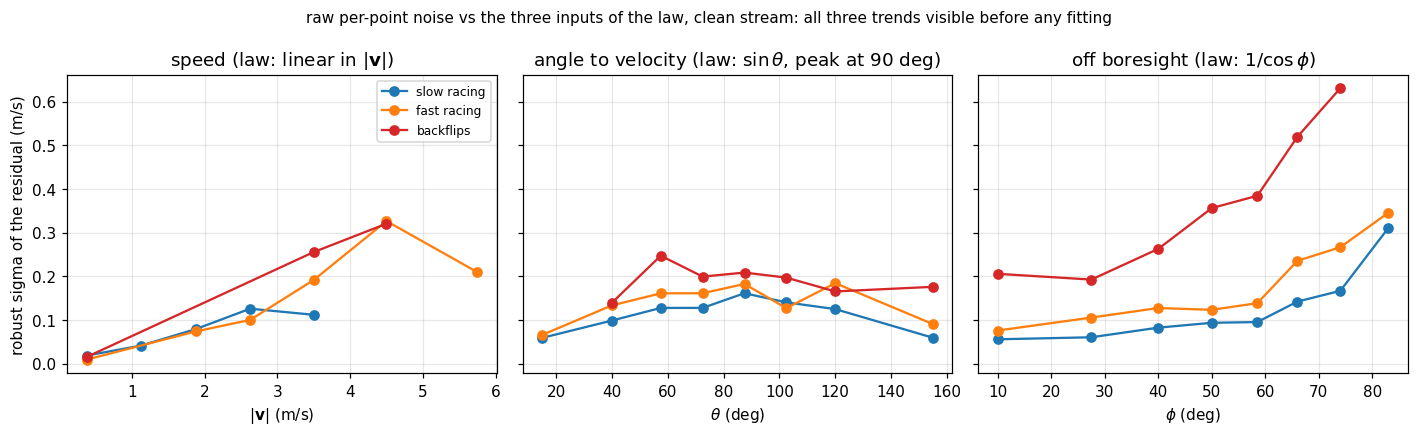

In [13]:
# Raw detection: per-point residual sigma vs each input of the law --
# speed |v|, ray-velocity angle theta, off-boresight angle phi.
# (Total residuals on the clean stream: an upper bound, it still carries the
#  frame-shared error -- but all three trends the law combines are already
#  visible raw, before any fitting, on every flight.)
V_BIN_EDGES = np.array([0, 0.75, 1.5, 2.25, 3, 4, 5, 6.5, 8])
TH_BIN_EDGES = np.array([0, 30, 50, 65, 80, 95, 110, 130, 180])
PHI_BIN_EDGES = np.array([0, 20, 35, 45, 55, 62, 70, 78, 88])
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for key in BAG_KEYS:
    dd = D[key]
    cl = ~dd['aliased']
    v_i = interp1d(dd['st_t'], np.array([s.velocity for s in dd['states']]),
                   axis=0, kind='linear', bounds_error=False,
                   fill_value='extrapolate')
    q_i = interp1d(dd['st_t'], np.array([s.orientation for s in dd['states']]),
                   axis=0, kind='linear', bounds_error=False,
                   fill_value='extrapolate')
    spd = np.empty(len(dd['r']))
    th = np.empty(len(dd['r']))
    cph = np.empty(len(dd['r']))
    for i_f in np.unique(dd['fi']):
        m = dd['fi'] == i_f
        fr = dd['radar'][int(i_f)]
        Pf = np.asarray(fr.positions, float)[dd['pi'][m]]
        s_j = Pf / np.maximum(np.linalg.norm(Pf, axis=1), 1e-6)[:, None]
        cph[m] = s_j[:, 0]
        v_b = quat_to_rotation_matrix(q_i(fr.timestamp + RADAR_OFF)).T \
            @ v_i(fr.timestamp + RADAR_OFF)
        nv = max(np.linalg.norm(v_b), 1e-6)
        spd[m] = nv
        u_b = (R_BS @ s_j.T).T
        th[m] = np.degrees(np.arccos(np.clip(u_b @ v_b / nv, -1, 1)))
    phi = np.degrees(np.arccos(np.clip(cph, -1, 1)))
    for ax, x, ed, tag in [(axes[0], spd, V_BIN_EDGES, 'v'),
                           (axes[1], th, TH_BIN_EDGES, 'theta'),
                           (axes[2], phi, PHI_BIN_EDGES, 'phi')]:
        c_r, s_r, _ = binned_sigma(x[cl], dd['r'][cl], ed)
        ax.plot(c_r, s_r, 'o-', color=COLOR[key],
                label=SHORT[key] if tag == 'v' else None)
        if tag == 'phi':
            print(f'{SHORT[key]:<13} sigma boresight -> 83 deg: '
                  f'{s_r[0]:.3f} -> {s_r[-1]:.3f} m/s ({s_r[-1]/s_r[0]:.1f}x)')
axes[0].set_xlabel('$|\\mathbf{v}|$ (m/s)')
axes[0].set_title('speed (law: linear in $|\\mathbf{v}|$)')
axes[1].set_xlabel('$\\theta$ (deg)')
axes[1].set_title('angle to velocity (law: $\\sin\\theta$, peak at 90 deg)')
axes[2].set_xlabel('$\\phi$ (deg)')
axes[2].set_title('off boresight (law: $1/\\cos\\phi$)')
axes[0].set_ylabel('robust sigma of the residual (m/s)')
axes[0].legend(fontsize=8)
fig.suptitle('raw per-point noise vs the three inputs of the law, clean stream: '
             'all three trends visible before any fitting', fontsize=10)
fig.tight_layout()


per-point predictor                  R^2      coef   floors sl/fa   rms bearing error at boresight
v sin      (BEARING, flat)         0.935   0.04292  0.041/0.064     3.5 deg
v sin/cos(phi)  (ARRAY)            0.979   0.02125  0.050/0.073     1.7 deg
sin/cos    (no speed)              0.835   0.05273  0.045/0.083     (ablation baseline)
v/cos      (no sin theta)          0.928   0.01709  0.036/0.068     (ablation baseline)
backflips floor refit (response frozen from racing): 0.202 m/s

LEAVE-ONE-FACTOR-OUT WHITENING: robust scale of d_j / sigma_j(model),
binned along each law input; each column compares the full law with the
law missing exactly that factor. A correct model gives 1.00 in every bin.


  sin/cos    (no speed)       slow racing  v    0.61 1.02 1.19 1.45   spread 2.37x
  v sin/cos(phi)  (ARRAY)     slow racing  v    0.77 1.05 1.06 1.13   spread 1.48x
  v/cos      (no sin theta)   slow racing  sin  0.77 0.93 0.87 1.02 0.99 1.29   spread 1.67x
  v sin/cos(phi)  (ARRAY)     slow racing  sin  1.05 1.08 0.92 0.97 0.84 1.03   spread 1.29x
  v sin      (BEARING, flat)  slow racing  phi  0.71 0.86 0.90 1.04 1.50   spread 2.11x
  v sin/cos(phi)  (ARRAY)     slow racing  phi  0.82 1.01 1.02 1.07 1.05   spread 1.31x
  sin/cos    (no speed)       fast racing  v    0.75 0.93 1.35 1.57   spread 2.09x
  v sin/cos(phi)  (ARRAY)     fast racing  v    0.83 0.97 1.19 1.11   spread 1.43x
  v/cos      (no sin theta)   fast racing  sin  0.80 0.86 0.80 1.02 1.08 1.01   spread 1.35x
  v sin/cos(phi)  (ARRAY)     fast racing  sin  1.16 1.07 0.87 1.00 1.00 0.87   spread 1.33x
  v sin      (BEARING, flat)  fast racing  phi  0.72 0.83 0.86 0.99 1.39   spread 1.92x
  v sin/cos(phi)  (ARRAY)     fa

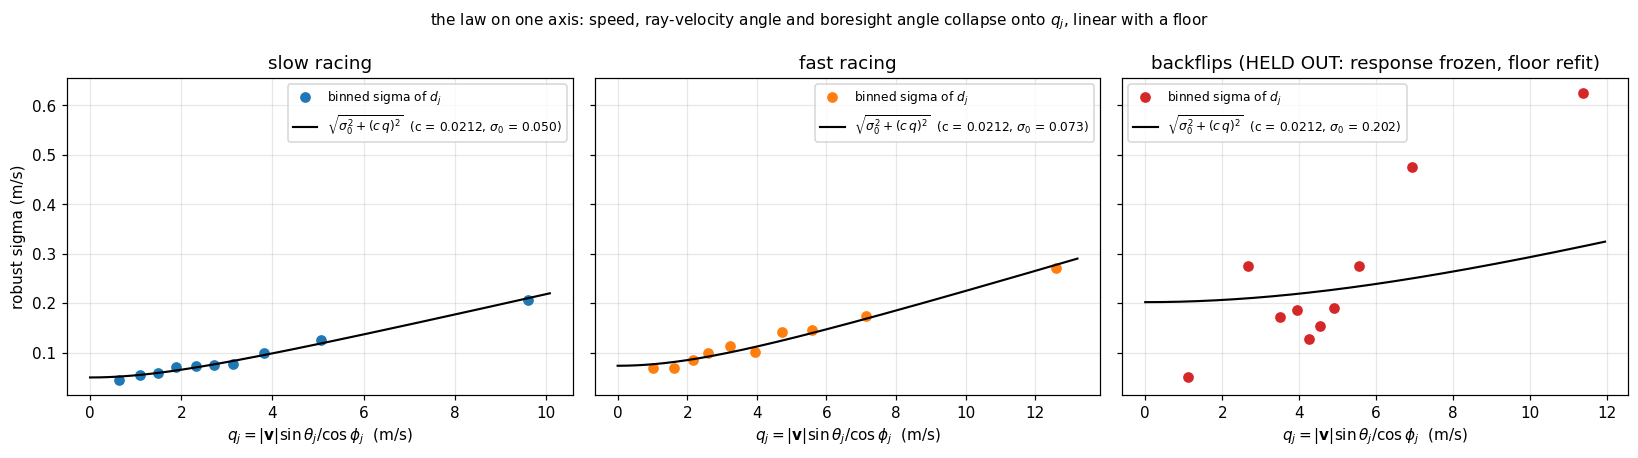

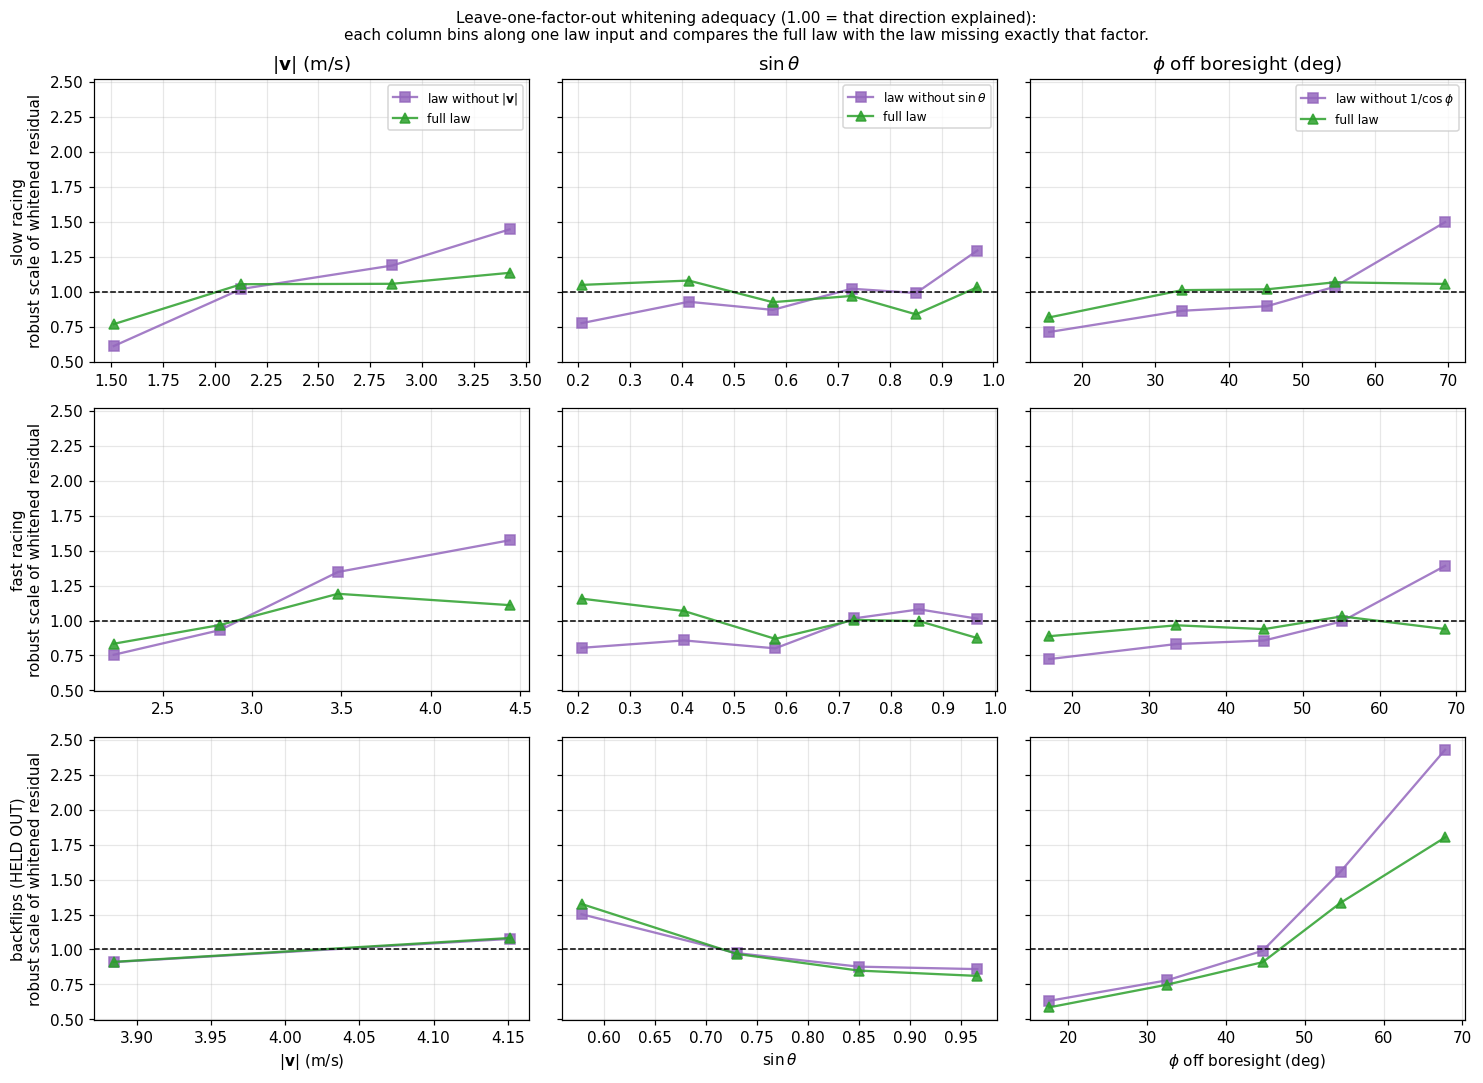

In [14]:
# The law fitted per return, and the test that decides it: whiten by each
# model's sigma_j and check what structure remains (a ranking can be argued
# with; a residual that still trends cannot).  Reduced to the bearing family;
# the full 8-candidate contest is notebook 11 / the worklog.
from scipy.optimize import least_squares as _ls

def point_table(key):
    d = D[key]
    keep0 = (np.abs(d['r'] - np.median(d['r'])) < 6 * robust_sigma(d['r'])) \
        & ~d['aliased']
    v_i = interp1d(d['st_t'], np.array([s.velocity for s in d['states']]),
                   axis=0, kind='linear', bounds_error=False,
                   fill_value='extrapolate')
    q_i = interp1d(d['st_t'], np.array([s.orientation for s in d['states']]),
                   axis=0, kind='linear', bounds_error=False,
                   fill_value='extrapolate')
    out = {k: [] for k in ('d', 'v', 'sin2', 'sx')}
    for f in np.unique(d['fi']):
        m = (d['fi'] == f) & keep0
        n = int(m.sum())
        if n < 6:
            continue
        fr = d['radar'][int(f)]
        v_b = quat_to_rotation_matrix(q_i(fr.timestamp + RADAR_OFF)).T \
            @ v_i(fr.timestamp + RADAR_OFF)
        nv = np.linalg.norm(v_b)
        if nv < 0.2:
            continue
        P = np.asarray(fr.positions, float)[d['pi'][m]]
        s_j = P / np.maximum(np.linalg.norm(P, axis=1), 1e-6)[:, None]
        u_b = (R_BS @ s_j.T).T
        out['sin2'].append(np.clip(1 - (u_b @ v_b / nv) ** 2, 0, 1))
        out['v'].append(np.full(n, nv))
        out['sx'].append(s_j[:, 0])
        out['d'].append((d['r'][m] - d['r'][m].mean()) / np.sqrt(1 - 1 / n))
    return {k: np.concatenate(v) for k, v in out.items()}

PT = {k: point_table(k) for k in BAG_KEYS}
RACING2 = ['slow_racing_best_velocity', 'fast_racing_best_velocity']
CPHI_FLOOR = 0.15    # 81.4 deg; a numerical guard binding on 0.5-1.9% of returns

def pred_X(T):
    s1 = np.sqrt(T['sin2'])
    cphi = np.maximum(T['sx'], CPHI_FLOOR)
    return {'v sin      (BEARING, flat)': T['v'] * s1,
            'v sin/cos(phi)  (ARRAY)   ': T['v'] * s1 / cphi,
            'sin/cos    (no speed)     ': s1 / cphi,
            'v/cos      (no sin theta) ': T['v'] / cphi}

def fit_pt(Xs, tabs, n_bins=10, min_n=120):
    c, s, b = [], [], []
    for bi, k in enumerate(tabs):
        X, T = Xs[k], tabs[k]
        ed = np.unique(np.percentile(X, np.linspace(0, 100, n_bins + 1)))
        for lo, hi in zip(ed[:-1], ed[1:]):
            m = (X >= lo) & (X < hi)
            if m.sum() >= min_n:
                c.append(X[m].mean()); s.append(robust_sigma(T['d'][m])); b.append(bi)
    c, s, b = np.array(c), np.array(s), np.array(b, int)
    nb_ = len(tabs)
    mdl = lambda th: np.sqrt(np.abs(th[b]) ** 2 + (np.abs(th[nb_]) * c) ** 2)
    th0 = np.r_[[np.median(s)] * nb_, [1e-3]]
    fsc = max(1.4826 * np.median(np.abs(s - np.median(s))), 1e-4)
    sol = _ls(lambda th: mdl(th) - s, th0, loss='soft_l1', f_scale=fsc,
              max_nfev=40000)
    r = mdl(sol.x) - s
    return np.abs(sol.x), 1 - float(r @ r) / float(((s - s.mean()) ** 2).sum())

tabs2 = {k: PT[k] for k in RACING2}
COEF = {}
print(f"{'per-point predictor':<32} {'R^2':>7} {'coef':>9} {'floors sl/fa':>14}"
      f"   rms bearing error at boresight")
for name in pred_X(PT[RACING2[0]]):
    Xs = {k: pred_X(PT[k])[name] for k in RACING2}
    th, r2 = fit_pt(Xs, tabs2)
    COEF[name] = th
    rd = (f'{np.degrees(th[2] * np.sqrt(2)):.1f} deg'
          if 'BEARING' in name or 'ARRAY' in name else '(ablation baseline)')
    print(f'{name:<32} {r2:>7.3f} {th[2]:>9.5f} {th[0]:>6.3f}/{th[1]:<7.3f}   {rd}')


# Backflips is held OUT of the fit (different error regime, sec-4 finding);
# for display it gets the honest transfer treatment: response (coef) frozen
# from racing, only its floor refit (the protocol of notebook 11's transfer
# test).
def refit_floor(name, key):
    T = PT[key]
    X = pred_X(T)[name]
    coef = COEF[name][2]
    ed = np.unique(np.percentile(X, np.linspace(0, 100, 9)))
    c_, s_ = [], []
    for lo, hi in zip(ed[:-1], ed[1:]):
        m = (X >= lo) & (X < hi)
        if m.sum() >= 60:
            c_.append(X[m].mean())
            s_.append(robust_sigma(T['d'][m]))
    c_, s_ = np.array(c_), np.array(s_)
    sol = _ls(lambda p: np.sqrt(p[0] ** 2 + (coef * c_) ** 2) - s_, [0.3],
              loss='soft_l1', max_nfev=20000)
    return abs(float(sol.x[0]))

BF = 'backflips_best_velocity'

def model_floor(name, key):
    th = COEF[name]
    return th[RACING2.index(key)] if key in RACING2 else refit_floor(name, key)

# The law on one axis: sigma of d_j binned against the combined predictor
# q_j = |v| sin(theta)/cos(phi), fitted curve overlaid.  Presentation, not
# discrimination: any predictor correlated with the true driver looks good on
# its own axis (the v^2 law did) -- the per-input whitening below is the test.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
NAME_ARR = 'v sin/cos(phi)  (ARRAY)   '
for ax, k in zip(axes, BAG_KEYS):
    X = pred_X(PT[k])[NAME_ARR]
    th = COEF[NAME_ARR]
    fl = model_floor(NAME_ARR, k)
    ed = np.unique(np.percentile(X, np.linspace(0, 100, 11)))
    cen, sig = [], []
    for lo, hi in zip(ed[:-1], ed[1:]):
        m = (X >= lo) & (X <= hi if hi == ed[-1] else X < hi)
        if m.sum() >= 60:
            cen.append(X[m].mean())
            sig.append(robust_sigma(PT[k]['d'][m]))
    assert cen, f'no filled q bins for {k}'
    ax.plot(cen, sig, 'o', color=COLOR[k], label='binned sigma of $d_j$')
    xg = np.linspace(0, max(cen) * 1.05, 200)
    ax.plot(xg, np.sqrt(fl ** 2 + (th[2] * xg) ** 2), 'k-', lw=1.4,
            label=f'$\\sqrt{{\\sigma_0^2 + (c\\,q)^2}}$  (c = {th[2]:.4f}, '
                  f'$\\sigma_0$ = {fl:.3f})')
    if k == BF:
        print(f'backflips floor refit (response frozen from racing): '
              f'{fl:.3f} m/s')
        ax.set_title(f'{SHORT[k]} (HELD OUT: response frozen, floor refit)')
    else:
        ax.set_title(SHORT[k])
    ax.set_xlabel('$q_j = |\\mathbf{v}|\\sin\\theta_j/\\cos\\phi_j$  (m/s)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('robust sigma (m/s)')
fig.suptitle('the law on one axis: speed, ray-velocity angle and boresight angle '
             'collapse onto $q_j$, linear with a floor', fontsize=10)
fig.tight_layout()

print()
print('LEAVE-ONE-FACTOR-OUT WHITENING: robust scale of d_j / sigma_j(model),')
print('binned along each law input; each column compares the full law with the')
print('law missing exactly that factor. A correct model gives 1.00 in every bin.')
STRATA = [
    ('$|\\mathbf{v}|$ (m/s)', 'v',
     np.array([0.2, 1.0, 1.75, 2.5, 3.25, 4.0, 5.0, 7.0])),
    ('$\\sin\\theta$', 'sin',
     np.array([0.0, 0.3, 0.5, 0.65, 0.8, 0.9, 1.0])),
    ('$\\phi$ off boresight (deg)', 'phi',
     np.array([0, 25, 40, 50, 60, 90])),
]
NAME_LAW = 'v sin/cos(phi)  (ARRAY)   '
ABL = {'v':   ('sin/cos    (no speed)     ', 'law without $|\\mathbf{v}|$'),
       'sin': ('v/cos      (no sin theta) ', 'law without $\\sin\\theta$'),
       'phi': ('v sin      (BEARING, flat)', 'law without $1/\\cos\\phi$')}
fig, axes = plt.subplots(3, 3, figsize=(13.5, 10), sharey=True)
for r_i, k in enumerate(BAG_KEYS):
    xs = {'v': PT[k]['v'],
          'sin': np.sqrt(PT[k]['sin2']),
          'phi': np.degrees(np.arccos(np.clip(PT[k]['sx'], -1, 1)))}
    for c_i, (xl, xk, ED) in enumerate(STRATA):
        ax = axes[r_i, c_i]
        for name, colr, mk, lab in [
                (ABL[xk][0], 'tab:purple', 's-', ABL[xk][1]),
                (NAME_LAW, 'tab:green', '^-', 'full law')]:
            th = COEF[name]
            X = pred_X(PT[k])[name]
            fl = model_floor(name, k)
            w = PT[k]['d'] / np.sqrt(fl ** 2 + (th[2] * X) ** 2)
            x = xs[xk]
            cen, cells_ = [], []
            for lo, hi in zip(ED[:-1], ED[1:]):
                m = (x >= lo) & (x < hi)
                if m.sum() >= 60:
                    cen.append(x[m].mean())
                    cells_.append(robust_sigma(w[m]))
            good = np.array(cells_)
            print(f'  {name[:26]:<27} {SHORT[k]:<12} {xk:<4} '
                  + ' '.join(f'{v_:.2f}' for v_ in cells_)
                  + f'   spread {good.max()/good.min():.2f}x')
            ax.plot(cen, cells_, mk, color=colr, alpha=0.85,
                    label=lab if r_i == 0 else None)
        ax.axhline(1.0, color='k', lw=1, ls='--')
        if r_i == 0:
            ax.set_title(xl)
            ax.legend(fontsize=8)
        if r_i == 2:
            ax.set_xlabel(xl)
        if c_i == 0:
            tag = ' (HELD OUT)' if k == BF else ''
            ax.set_ylabel(f'{SHORT[k]}{tag}\nrobust scale of whitened residual')
fig.suptitle('Leave-one-factor-out whitening adequacy (1.00 = that direction '
             'explained):\neach column bins along one law input and compares the '
             'full law with the law missing exactly that factor.', fontsize=10)
fig.tight_layout()


<font color='red'>try fit on all bags together for joint sigma_0. does this work?</font>

<font color='red'>sin(theta) hat keinen effekt. darf man das dann einfach löschen? - "papers präsentieren nur das, was geklappt hat. ist schmerzvoll all die nicht funktionierenden experimente wegzuwerfen, aber so ist es eben. passt also</font>

**Finding (the law, its constant, and its mechanism).** The per-return Doppler
noise is a bearing error, linear in speed, growing off boresight:
$\delta\phi_0 \approx 2^\circ$ rms at boresight

**Per-return weighting composed naively did not improve all bags** (table
below) -- the cost was a composition defect, not the law. With the exact
per-frame covariance ($\Sigma_f = \mathrm{diag}(\sigma_0^2/w_j) +
\sigma_c^2\mathbf v\mathbf v^\top$, channel-matched $\sigma_c = 1.27$) and the
duplicate-detection collapse on the raw-detection bag, it passes all eight
flights and **is the deployed model since 2026-08-12**, with the Huber knee
per return in the same model ($\delta_j = \delta/\sqrt{w_j}$,
parameter-free). Accepted cost: $+0.2$-$0.3$ pp ICINS drift with zero
per-platform calibration (their measured $\sigma_c$ 0.93 would close
35-58 %). `worklog/2026-08-12_per-return-adoption.md`

| flight | velocity | orientation | drift |
|---|---|---|---|
| slow racing | $-8.3\,\%$ | $-0.07^\circ$ | $-0.10$ pp |
| fast racing | $-8.6\,\%$ | $-0.03^\circ$ | $-0.12$ pp |
| backflips | $-1.1\,\%$ | $\mathbf{+0.22^\circ}$ | $+1.6$ pp |
| fast2, held out | $-2.1\,\%$ | $\mathbf{+0.11^\circ}$ | $-0.07$ pp |

## 5. The constant weights

Section 4 measured the radar's *dynamic* trust: which return deserves how much
weight, given the flight state. This section derives the three *static*
constants that set how much each **stream** is trusted relative to the others,
radar against gyroscope against accelerometer. They were hand-tuned for most
of this project's life (4.0 / 0.01 / 1.0); here they are derived from measured
quantities.

**The idea in three sentences.** A weight in the least-squares cost is a claim
about how much *independent* information a stream delivers. Sampling rate is
not information rate: samples whose errors are correlated repeat each other,
so a stream sampled at $f_s$ whose errors stay correlated over a time $\tau$
delivers about $1/\tau$ independent errors per second, not $f_s$. The
statistically meaningful weight is therefore the inverse variance per
*independent* error:

$$ \boxed{\;\lambda^\ast = \frac{1}{\sigma^2\, f_s\, \tau}\;} $$

A white-noise stream has $\tau = 1/f_s$ and recovers the textbook
$\lambda = 1/\sigma^2$ per sample, so the formula corrects the naive weight
rather than contradicting it.

Both inputs are measured per stream, on the same estimator-free residuals as
everything else in this notebook:

- $\tau$ is the measured **integrated autocorrelation time** of that residual.
  It applies to all three streams and matters most for the IMU: $\tau$ = 194-598 ms,
  so 1000 Hz sampling delivers a few independent errors per second rather than
  a thousand. 

<details>
<summary><b>Unfold: where the formula comes from, how tau is measured, and the Huber subtlety</b></summary>

**From the variance of a mean.** Estimate a constant offset $b$ from a window
of length $T$ sampled at $f_s$. With independent noise,
$\mathrm{Var}(\hat b) = \sigma^2/(f_s T)$. With noise that decorrelates over a
time $\tau$, the classical result for autocorrelated series is
$\mathrm{Var}(\hat b) = \sigma^2\tau/T$: the window holds $T/\tau$ independent
errors. A per-sample weight $\lambda$ in a least-squares cost claims
$\mathrm{Var}(\hat b) = 1/(\lambda f_s T)$; matching the claim to the truth
gives the boxed formula. Equivalently, the curvature (Fisher information) of
the weighted cost, $2\lambda f_s T$, is set equal to the true information
$2(T/\tau)/\sigma^2$ for a parameter that shifts all residuals equally. This
is the classic *effective sample size* correction with $\tau$ the *integrated
autocorrelation time*, standard time-series statistics rather than anything
invented here; in the white limit it reduces to the familiar IMU
noise-density bookkeeping used in preintegration.

**What happens without it.** Naive per-sample inverse variance gives
$\lambda_\mathrm{gyro} = 1/\sigma^2 \approx 1700$, counted 1000 times per
second, overstating the gyro's information by $f_s\tau \approx$ 200-600x; the
radar is crushed. The derived 3.13 lands within a factor 1.3 of the 4.0 that
years of hand-tuning converged to: the tuning had implicitly discovered this
correction, and the formula says why the answer is ~3 and not ~1700.

**How $\tau$ is measured.** For the regularly sampled gyro and accel: the
empirical lag autocorrelation of the in-band residual, summed to its first
zero crossing, $\tau = \Delta t\,(1 + 2\sum_{k\ge1}\rho_k)$, averaged over the
three axes (truncating at the first non-positive lag is the standard practical
estimator). For the irregular radar stream: products of all point pairs closer
than 3 s in time, averaged in 50 ms lag bins, give $\rho(\Delta)$, and
$\tau = 1/\mathrm{rate} + 2\int\rho(\Delta)\,d\Delta$ with the same
truncation. All returns of a frame share one timestamp, so within-frame pairs
land at $\Delta \approx 0$: the frame-shared error fills the first bin and
contributes most of the radar's $\tau$. Two caveats ride along: the 10 Hz
low-pass alone would induce only a few tens of ms of correlation (the measured
194-598 ms is real structure, not the filter), and the gyro's reference is
partly circular (the MoCap-side rate estimate fuses the gyro;
$\sigma_\mathrm{gyro}$ measured ~25 % low,
`worklog/2026-08-09_imu-reference-is-partly-circular.md`).

**The Huber subtlety, exactly.** Radar residuals pass through a Huber loss
whose influence is capped at $\delta$, and the asymptotic information per
residual of an M-estimator is $(\mathbb{E}[\psi'])^2/\mathbb{E}[\psi^2]$
(Huber 1964). For the Huber loss
$\mathbb{E}[\psi(r)^2] = \mathbb{E}[\min(|r|,\delta)^2] = \sigma_\mathrm{cap}^2$
exactly, so $\lambda^\ast = 1/(\sigma_\mathrm{cap}^2 f_s \tau)$ is the
sandwich information rate up to the denominator correction
$(\mathbb{E}[\psi'])^2$, the squared kept fraction inside $\delta$, measured
at 0.999/0.94 on the two racing streams (printed below): a $\le 6\,\%$
effect, far below the per-bag spread. The empirical behaviour confirms the
theory rather than motivating it: the idealized Gaussian-core $\sigma$ (the
wrong moment for a Huberized stream) gives per-flight weights 3.1/11.1 and
fails the gates at their geomean; the capped moment reconciles them (1.9 vs
2.3 in the canonical `analysis/derive_stream_weights.py`, geometric mean 2.11
= the deployed value) and passes.
</details>

The cell below is a compact in-notebook reimplementation of that script.


In [15]:
# Deriving the statics: lambda* = 1 / (sigma^2 * rate * tau_corr).
# A stream's usable information per second is capped by its in-band residual
# width AND its error correlation time (samples inside tau repeat information).
# One formula for all streams; for radar, sigma must be the INFLUENCE-CAPPED
# width sqrt(E[min(|r|, delta)^2]) of the prefiltered stream (the second moment
# that enters the Huber normal equations) -- the idealized core width gives
# per-flight weights that disagree 3.6x and fail end-to-end.
from scipy.signal import butter, filtfilt

def corr_time_reg(x, dt):
    x = x - x.mean()
    ac = np.correlate(x, x, 'full')[len(x) - 1:]
    ac = ac / ac[0]
    tau = dt
    for k in range(1, min(len(ac), 8000)):
        if ac[k] <= 0:
            break
        tau += 2 * ac[k] * dt
    return tau

def corr_time_irr(t, x, max_lag=3.0, bin_w=0.05):
    x = x - x.mean(); var = np.mean(x ** 2)
    o = np.argsort(t); t, x = t[o], x[o]
    n = len(t); nb = int(max_lag / bin_w)
    num = np.zeros(nb); cnt = np.zeros(nb); jh = 0
    for i in range(n):
        while jh < n and t[jh] - t[i] < max_lag:
            jh += 1
        for j in range(i + 1, jh):
            b = int((t[j] - t[i]) / bin_w)
            num[b] += x[i] * x[j]; cnt[b] += 1
    rho = np.clip(np.where(cnt > 50, num / np.maximum(cnt, 1) / var, 0.0), 0, None)
    tau = 0.0
    for b in range(nb):
        if rho[b] <= 0 and b > 2:
            break
        tau += 2 * rho[b] * bin_w
    return 1.0 / (n / (t[-1] - t[0])) + tau

RACING = ['slow_racing_best_velocity', 'fast_racing_best_velocity']
lam = {'gyro': [], 'accel': [], 'radar': []}
naive = {'gyro': [], 'accel': [], 'radar': []}   # per-sample 1/sigma^2, no tau
print(f"{'bag':<13} {'stream':<6} {'sigma':>7} {'rate':>7} {'tau':>7} {'lambda*':>8}")
for key in RACING:
    d = D[key]
    t_imu = np.array([m.timestamp for m in d['imu']]) + IMU_OFF
    fs = 1.0 / np.median(np.diff(t_imu))
    b, a = butter(2, 10.0 / (fs / 2), btype='low')
    # gyro / accel: in-band residual width + correlation time
    g_res = np.array([m.angular_velocity for m in d['imu']]) - d['om_interp'](t_imu)
    g_res -= np.median(g_res, axis=0)
    g_ib = filtfilt(b, a, g_res, axis=0)
    ac_i = interp1d(d['st_t'], np.array([s.acceleration for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False, fill_value='extrapolate')
    qu_i = interp1d(d['st_t'], np.array([s.orientation for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False, fill_value='extrapolate')
    acc = np.array([m.linear_acceleration for m in d['imu']])
    a_w = ac_i(t_imu); qq = qu_i(t_imu)
    a_res = np.empty_like(acc)
    for i in range(len(t_imu)):
        a_res[i] = acc[i] - quat_to_rotation_matrix(qq[i]).T @ (a_w[i] - np.array([0, 0, -9.81]))
    a_res -= np.median(a_res, axis=0)
    a_ib = filtfilt(b, a, a_res, axis=0)
    for name, ib in [('gyro', g_ib), ('accel', a_ib)]:
        sig = robust_sigma(ib.ravel())
        tau = np.mean([corr_time_reg(ib[:, k], 1 / fs) for k in range(3)])
        lv = 1.0 / (sig ** 2 * fs * tau)
        lam[name].append(lv)
        naive[name].append(1.0 / sig ** 2)
        print(f'{SHORT[key]:<13} {name:<6} {sig:>7.3f} {fs:>6.0f}/s {1e3*tau:>5.0f}ms {lv:>8.4g}')
    # radar: prefiltered CLEAN stream (aliased excluded -- the reference
    # population the per-point channel normalizes to 1 against; the deployed
    # 2.11 was derived on the kept stream incl. aliased survivors, a recorded
    # conservative bias)
    rr = d['r'] - np.median(d['r'])
    t_pts = np.array([d['radar'][i].timestamp for i in d['fi']]) + RADAR_OFF
    kmask = np.zeros(len(rr), bool)
    for i, m in masks[key].items():
        sel = d['fi'] == i
        for j in np.where(sel)[0]:
            if d['pi'][j] < len(m):
                kmask[j] = m[d['pi'][j]]
    kmask &= ~d['aliased']
    rk, tk = rr[kmask], t_pts[kmask]
    rate_r = len(rk) / (tk.max() - tk.min())
    s_cap = np.sqrt(np.mean(np.minimum(np.abs(rk), 1.0) ** 2))
    xc = np.sign(rk) * np.minimum(np.abs(rk), 1.0)
    tau_r = corr_time_irr(tk, xc)
    lv = 1.0 / (s_cap ** 2 * rate_r * tau_r)
    lam['radar'].append(lv)
    naive['radar'].append(1.0 / s_cap ** 2)
    e_psi = np.mean(np.abs(rk) < 1.0)
    print(f'{SHORT[key]:<13} {"radar":<6} {s_cap:>7.3f} {rate_r:>6.0f}/s '
          f"{1e3*tau_r:>5.0f}ms {lv:>8.4g}  E[psi']={e_psi:.4f}")

gm = {k: float(np.sqrt(v[0] * v[1])) for k, v in lam.items()}
print(f"\nDERIVED (geometric mean over the racing calibration flights):")
print(f"  lambda_gyro*  = {gm['gyro']:.3g}   (deployed 3.13; was tuned 4.0)")
print(f"  lambda_accel* = {gm['accel']:.3g}  (deployed 0.00392; was tuned 0.01)")
print(f"  radar_weight* = {gm['radar']:.3g}   (clean stream; deployed 2.11 = "
      f"mixed-stream protocol, conservative; redeploy needs gates)")
gn = {k: float(np.sqrt(v[0] * v[1])) for k, v in naive.items()}
print('\nnaive per-sample 1/sigma^2 (same sigmas, NO correlation-time correction):')
for s in ('gyro', 'accel', 'radar'):
    print(f'  {s:<6} {gn[s]:>8.3g}   ({gn[s]/gm[s]:>4.0f}x the derived value; the ratio is f_s tau)')


bag           stream   sigma    rate     tau  lambda*


slow racing   gyro     0.024    997/s   194ms    8.959


slow racing   accel    0.447    997/s   598ms 0.008384


slow racing   radar    0.107    123/s   356ms    1.983  E[psi']=0.9997


fast racing   gyro     0.051    996/s   356ms    1.095


fast racing   accel    1.106    996/s   448ms 0.001833


fast racing   radar    0.198     80/s    96ms    3.321  E[psi']=0.9845

DERIVED (geometric mean over the racing calibration flights):
  lambda_gyro*  = 3.13   (deployed 3.13; was tuned 4.0)
  lambda_accel* = 0.00392  (deployed 0.00392; was tuned 0.01)
  radar_weight* = 2.57   (clean stream; deployed 2.11 = mixed-stream protocol, conservative; redeploy needs gates)

naive per-sample 1/sigma^2 (same sigmas, NO correlation-time correction):
  gyro        819   ( 262x the derived value; the ratio is f_s tau)
  accel      2.02   ( 516x the derived value; the ratio is f_s tau)
  radar      47.1   (  18x the derived value; the ratio is f_s tau)


### Aliased returns: partial information

Section 2 established that aliasing is not a corner case on this sensor: at
$v_\mathrm{max} = 3.14$ m/s against a platform that routinely exceeds it, 2 % of
slow-racing returns wrap, 24 % of fast-racing and 38 % of backflip returns. The
question this section answers is what to *do* with them, and the answer is not
obvious, because an aliased return is damaged rather than useless.

**Why it is partial rather than worthless.** The Doppler itself is recoverable, What cannot be recovered
is the bearing. The on-chip angle estimate was computed from the *wrapped*
velocity (TDM Doppler compensation), so it is wrong in a way no downstream
processing can undo.

3 options: keep, remove, downweight

In [16]:
# The measured facts behind the alias weight:
# 1. aliased returns have a regime-FLAT absolute error floor sigma_al ~ 0.6 m/s,
# 2. the clean per-point floor is s0 = 0.082 m/s (racing geomean).  NOTE the
#    provenance: 0.082 is the geomean of the speed-QUADRATIC fit's floors
#    (0.072/0.094) -- a superseded fit.  It survives that supersession
#    by luck rather than by right: the adopted law's own pairwise fit gives
#    s0 = 0.083 (characterize_shape_contradiction.py --block deploy), so the
#    alias weight below is insensitive to which fit supplies the floor.
# so inverse variance gives a CONSTANT aliased weight w_al = (s0/sigma_al)^2.
print(f"{'bag':<14} {'sigma aliased':>14} {'sigma clean':>12} {'(cl/al)^2':>11}")
for key in BAG_KEYS:
    d = D[key]
    al = d['aliased']
    if al.sum() < 30:
        continue
    s_al = robust_sigma(d['r'][al]); s_cl = robust_sigma(d['r'][~al])
    print(f'{SHORT[key]:<14} {s_al:>14.3f} {s_cl:>12.3f} {(s_cl/s_al)**2:>11.2f}')
print(f"\ndeployed constant: w_al = (0.082 / 0.6)^2 = {(0.082/0.6)**2:.3f}")

# The comparison above mixes statistics: sigma_al is a TOTAL, pooled, robust
# width over points that are aliased precisely BECAUSE they are fast, while
# sigma_0 = 0.082 is a within-frame, low-speed floor.  Redo it like for like --
# reference-immune deviations, aliased and clean measured against the same
# CLEAN frame mean, binned by speed.  (analysis/characterize_reference_immune.py)
print()
print('like-for-like: within-frame deviations, matched speed bins')
print(f"  {'bag':<13} {'|v| bin':>9} {'clean':>8} {'aliased':>9} {'ratio':>7}")
V_ED = np.array([0, 2, 3, 4, 5, 7])
for key in BAG_KEYS:
    d = D[key]
    clean = ~d['aliased']
    v_i2 = interp1d(d['st_t'], np.array([s.velocity for s in d['states']]),
                    axis=0, kind='linear', bounds_error=False,
                    fill_value='extrapolate')
    t_p = np.array([d['radar'][i].timestamp for i in d['fi']]) + RADAR_OFF
    v_p = np.linalg.norm(v_i2(t_p), axis=1)
    dev_c, idx_c, dev_a, idx_a = [], [], [], []
    for f in np.unique(d['fi']):
        mc = (d['fi'] == f) & clean
        ma = (d['fi'] == f) & d['aliased']
        if mc.sum() < 6:
            continue
        mu = d['r'][mc].mean()
        dev_c.append((d['r'][mc] - mu) / np.sqrt(1 - 1 / mc.sum()))
        idx_c.append(np.flatnonzero(mc))
        if ma.sum():
            dev_a.append(d['r'][ma] - mu)
            idx_a.append(np.flatnonzero(ma))
    if not dev_a:
        continue
    dev_c, idx_c = np.concatenate(dev_c), np.concatenate(idx_c)
    dev_a, idx_a = np.concatenate(dev_a), np.concatenate(idx_a)
    for lo, hi in zip(V_ED[:-1], V_ED[1:]):
        mc = (v_p[idx_c] >= lo) & (v_p[idx_c] < hi)
        ma = (v_p[idx_a] >= lo) & (v_p[idx_a] < hi)
        if mc.sum() >= 40 and ma.sum() >= 40:
            sc, sa = robust_sigma(dev_c[mc]), robust_sigma(dev_a[ma])
            print(f'  {SHORT[key]:<13} {lo:>4.0f}-{hi:<4.0f} {sc:>8.3f} '
                  f'{sa:>9.3f} {sa/sc:>6.1f}x')


bag             sigma aliased  sigma clean   (cl/al)^2
slow racing             0.620        0.094        0.02
fast racing             0.718        0.138        0.04
backflips               0.524        0.279        0.28

deployed constant: w_al = (0.082 / 0.6)^2 = 0.019

like-for-like: within-frame deviations, matched speed bins
  bag             |v| bin    clean   aliased   ratio
  slow racing      3-4       0.145     0.289    2.0x
  fast racing      3-4       0.275     1.268    4.6x
  fast racing      4-5       0.329     0.793    2.4x
  backflips        3-4       0.212     0.717    3.4x
  backflips        4-5       0.264     0.720    2.7x


aliased returns
are about **2 to 4.6x** noisier than clean ones, 

| bag | keep $w=1$ | delete | down-weight |
|---|---|---|---|
| slow | 0.179/1.71/0.59 | 0.177/1.71/0.57 | 0.180/1.71/0.59 |
| fast | 0.316/2.58/1.17 | 0.317/2.77/1.14 | **0.297/2.56/0.92** |
| fast2 (held-out) | 0.455/2.69/2.18 | 0.511/2.68/1.57 | **0.396/2.64/1.60** |
| backflips | 2.18/8.32/18.3 | 2.23/8.41/11.3 | 2.37/8.17/11.0 |

(Provenance: measured at the rate-era rule, whose net constant was 0.025,
30% above the current 0.019; a later full gate battery revalidated the
0.019 end to end.)


### The full weight composition, stream by stream

Everything the weighting sections derived, composed as each residual actually
enters the deployed cost. Gyro (pure L2, no dynamic factor since the rate-boost
deletion):

$$ \Lambda^{\mathrm{gyro}} \;=\; \lambda_g^\ast \qquad (= 3.13,\ \text{section 5}) $$

Accelerometer (L2 core, the one empirical gate, and its own wide Huber
backstop):

$$ \Lambda^{\mathrm{accel}} \;=\; \lambda_a^\ast
   \cdot \frac{1}{1 + (\lvert\boldsymbol\omega\rvert/\omega_a)^2}
   \cdot h_{\delta_a}(r), \qquad
   \lambda_a^\ast = 0.00392,\quad \omega_a = 8\ \mathrm{rad/s},\quad
   \delta_a = 2\ \mathrm{m/s^2} $$

Radar, per return $j$ of frame $f$ -- the longest chain, one factor per
measured mechanism:

$$ \Lambda^{\mathrm{radar}}_{f,j} \;=\; \lambda_r^\ast
   \cdot w_{f,j} \cdot h_{\delta_j}(r_{f,j}), \qquad
   w_{f,j} = \begin{cases}
     1 \,/\, \big(1 + (\sigma_u\,q_{f,j}/\sigma_0)^2\big) & \text{clean} \\
     w_{\mathrm{al}} = 0.019 & \text{aliased}
   \end{cases} $$

with $q_{f,j} = |\mathbf v_f|\sin\theta_j/\cos\phi_j$ each return's own
geometry (section 4's law, per return -- deployed 2026-08-12), and $\mathbf v_f$ the frame's own WLS-consensus ego-velocity -- a radar-only input (measured 0.05-0.13 m/s against MoCap; the IMU enters the front end only through alias unwrapping). Applied inside
the frame's exact whitened stack
$\Sigma_f = \mathrm{diag}(\sigma_0^2/w_j) + \sigma_c^2\,\mathbf v\mathbf v^\top$,
$\mathbf v_j = \sqrt{w_j}$, $\sigma_c = 1.27$ measured on this weight
channel. Huber knee per return at a fixed number of model sigmas,
$\delta_j = \delta/\sqrt{w_{f,j}}$ (parameter-free). Estimator-side
companion: staleness inflation of the marg prior's orientation rows
($\sigma_\mathrm{add} = 0.01\,\theta_\mathrm{swept}$, measured against GT).
Legacy per-frame arm: `radar_weight_model: speed`.


## 6. The derived configuration, end to end (velocity first)

Everything above compiles into one flag-free configuration, identical for all
bags and platforms: the derived statics of section 5, the **per-return law
inside the exact frame covariance**, the constant alias weight, the
model-sigma Huber knee, the RANSAC prefilter of section 3, the
staleness-inflated marginalization prior, grids 40/16 ms, heading weight 0.6,
extrinsics locked at the measured pitch. No per-bag knobs. Velocity first:
it is the quantity the radar measures; position is its integral.

| Flight | velocity (m/s) | orientation (deg) | drift (%) |
|---|---|---|---|
| slow racing | **0.18** | 1.7 | 0.82 |
| fast racing | **0.28** | 2.6 | 1.01 |
| backflips (hardest regime, no rescue terms) | 2.04 | 7.8 | 7.4 |
| fast2, held out of every fit | **0.28** | 2.8 | 1.9 |
| ICINS 1-4 (different platform, unchanged config) | **0.07-0.09** | 0.6-1.4 | 0.25-0.65 |

Backflips: hardest regime, carried honestly (38 % aliased, elevated floor, a
2.6x larger bearing constant); best backflips velocity of any configuration
tested. fast2 runs the raw-detection collapse front end (recording-artifact
repair, not tuning). ICINS: only the dataset's own extrinsics change --
**no parameter is calibrated to their platform**; the measured per-platform
$\sigma_c$ (0.93 vs deployed 1.27) would close 35-58 % of the remaining
drift gap. (Sources: the 2026-08-12 adoption runs; the live demo below
reproduces the slow-racing row.)

**Sensor ablation** 

| Configuration | slow racing | fast racing |
|---|---|---|
| full system | 0.21 / 1.8 / 1.12 | 0.28 / 2.6 / 1.05 |
| no accelerometer | 0.22 / 3.0 / 0.44 | 0.75 / 2.7 / 2.77 |
| no IMU (radar + heading) | 3.70 / 155 / 13.1 | 1.06 / 88 / 3.69 |
| no radar (IMU + heading) | 2.4 / 8.9 / 5.9 | 8.0 / 4.0 / ~100 |

Radar and gyroscope are the two load-bearing streams: without the IMU,
attitude collapses (radar constrains it only weakly through the lever arm);

In [17]:
# Run the real C++ sliding-window solver (~1 min on slow racing). Set RUN_SOLVER=False to skip.
import re
import subprocess

RUN_SOLVER = True
BAG = 'slow_racing_best_velocity'      # try 'fast_racing_best_velocity' too

if RUN_SOLVER:
    cmd = [sys.executable, 'validate_live_solver.py', BAG,
           '--mocap-yaw', '--cpp', '--sliding-window',
           '--set', 'marg_prior_scale=1.0',
           '--set', 'accel_soft_sigma=8.0',
           '--set', 'dt_pos=0.04', '--set', 'dt_ori=0.016',
           '--set', 'lambda_heading=0.6', '--set', 'lock_extrinsics=1',
           '--set-ext', 'rotation_euler_deg=[180.0,27.5,0.0]']
    if BAG.startswith('backflips'):
        cmd += ['--set', 'lock_gyro_bias=0']   # undo a batch-era bags.yaml override
    print('$', ' '.join(cmd[1:]), '\n')
    proc = subprocess.run(cmd, cwd=str(ANALYSIS), capture_output=True, text=True,
                          timeout=3600)
    out = proc.stdout
    m = re.search(r'=== RESULTS', out)
    print(out[m.start():] if m else out[-4000:])
    if proc.returncode != 0:
        print('STDERR tail:\n', proc.stderr[-2000:])

$ validate_live_solver.py slow_racing_best_velocity --mocap-yaw --cpp --sliding-window --set marg_prior_scale=1.0 --set accel_soft_sigma=8.0 --set dt_pos=0.04 --set dt_ori=0.016 --set lambda_heading=0.6 --set lock_extrinsics=1 --set-ext rotation_euler_deg=[180.0,27.5,0.0] 



=== RESULTS (mocap-init+mocap-heading+gyro) — settled vs live (76 windows) ===
  Metric                          Settled   Live edge         Δ
  ---------------------------- ----------  ----------  --------
  Position RMSE (m)                0.4791  0.3997   -0.0793
  Position drift (%)                0.99%  0.82%   -0.1631
    horizontal (xy) RMSE (m)       0.2417   (drift 0.50%)
    vertical (z) RMSE (m)          0.4136   (drift 0.85%)
  Velocity RMSE (m/s)              0.1162  0.1767   +0.0605
  Angular vel RMSE (rad/s)         0.2004
  Acceleration RMSE (m/s²)         0.9963
  Orientation RMSE (deg)           1.1058  1.6746   +0.5687
  Per-axis ori RMSE: roll=0.783  pitch=0.561  yaw=0.679 deg
  Acc bias: [-0.0051, 0.0490, 0.2393] m/s²
  Gyr bias: [0.0008, -0.0029, 0.0025] rad/s
  Live eval range: [2.629, 22.999] s  (6092 MoCap pts)

--------------------------------Generating Plots--------------------------------
  Saved: /home/mouse/MyData/radar-iwr6843-driver/plots/slow_racing_bes

live_validation_slow_racing_best_velocity_mocap-init_mocap-heading_20260813_084508.png


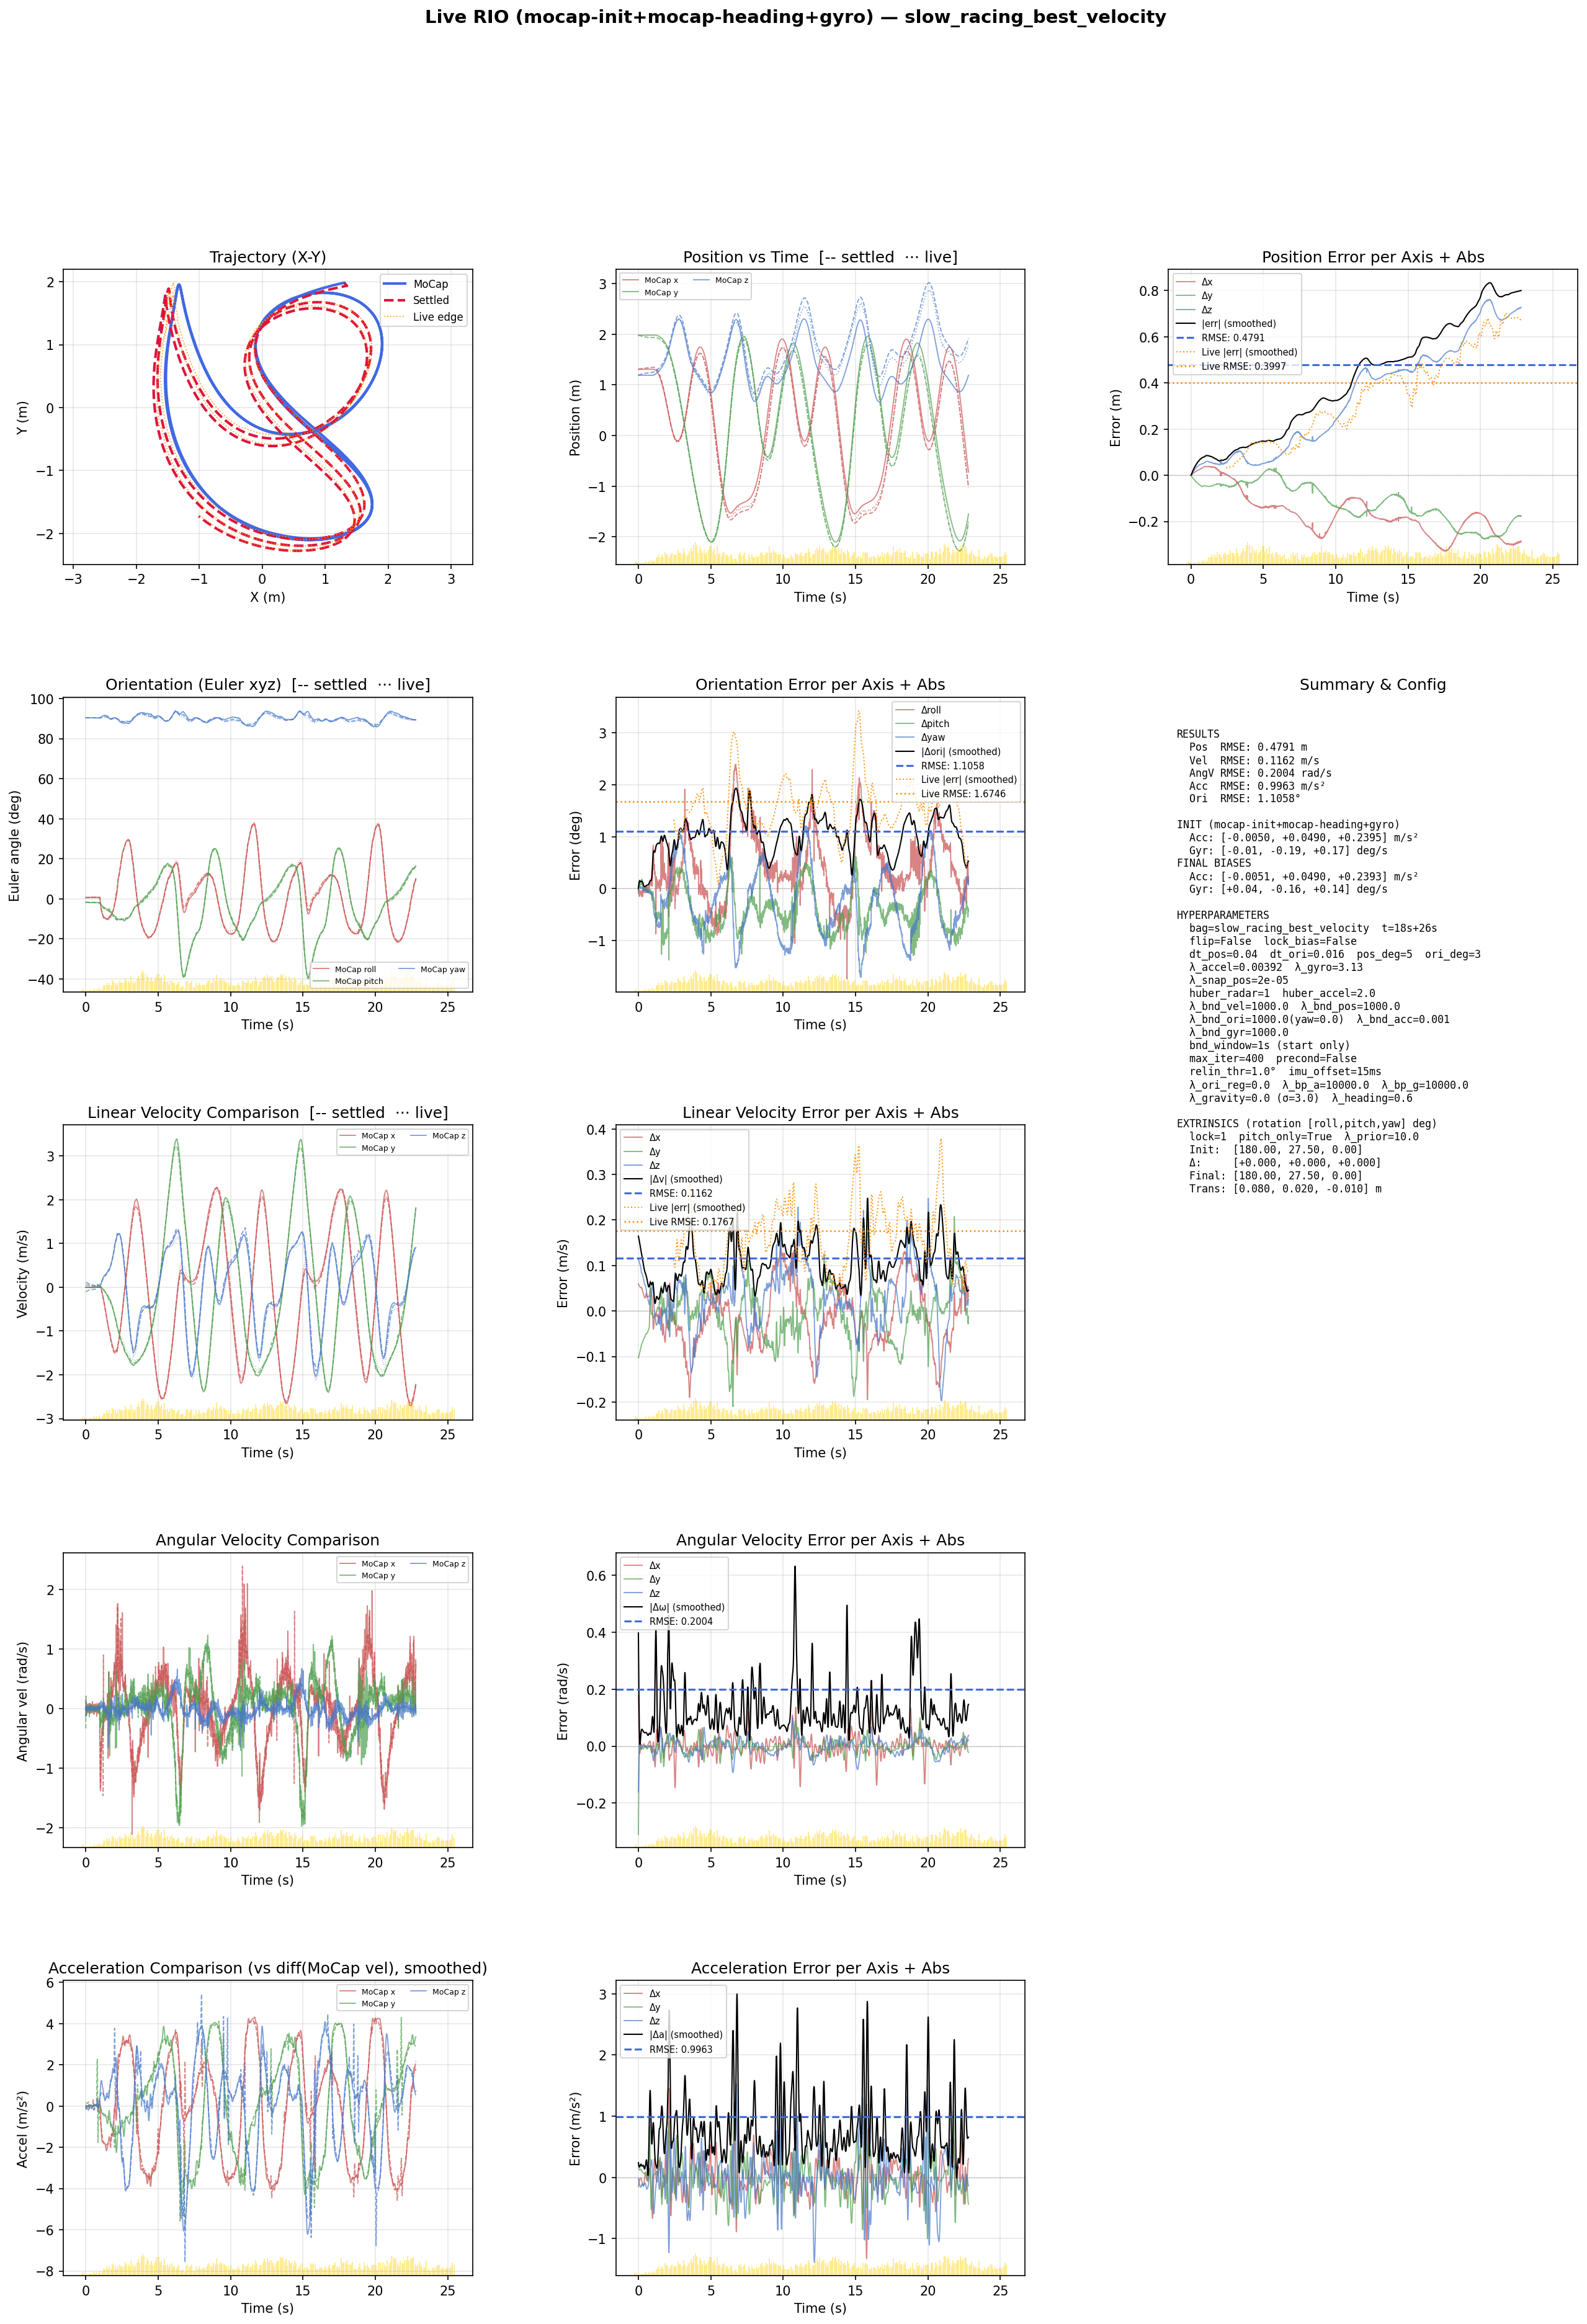

In [18]:
# Display the trajectory/error plot the run just saved
from IPython.display import Image, display

if RUN_SOLVER:
    plot_dir = REPO_ROOT / 'plots' / BAG / 'live_solver'
    pngs = sorted(plot_dir.glob('live_validation_*.png'),
                  key=lambda p: p.stat().st_mtime)
    if pngs:
        print(pngs[-1].name)
        display(Image(str(pngs[-1]), width=980))